<a href="https://colab.research.google.com/github/Kittiphat-673020244-3/SC663402-Data-Warehouse-and-Big-Data-Analytics-2026/blob/main/%E0%B8%81%E0%B8%B4%E0%B8%95%E0%B8%95%E0%B8%B4%E0%B8%9E%E0%B8%B1%E0%B8%A8_673020244_3_SC663402_Pandas_Review.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# SC 663 402 Data Warehouse and Big Data Analytics
## แบบฝึกทบทวน pandas

**ผู้สอน:** อ.ดร.พิชญา วิรัชโชติเสถียร (Pitchaya Wiratchotisatian)
**ภาควิชาสถิติ คณะวิทยาศาสตร์ มหาวิทยาลัยขอนแก่น**

---

### วัตถุประสงค์

การบ้านชุดนี้มีวัตถุประสงค์เพื่อทบทวนความรู้ pandas ที่นักศึกษาเคยศึกษามาแล้ว ให้อยู่ในระดับที่พร้อมสำหรับการวิเคราะห์ข้อมูลขนาดใหญ่ในรายวิชานี้
เนื้อหาครอบคลุมตั้งแต่โครงสร้างข้อมูลพื้นฐาน การเลือกและกรองข้อมูล การสรุปข้อมูลด้วย `groupby` การรวมตารางหลายตาราง จนถึงการสร้างกราฟจาก DataFrame

### รูปแบบ

แต่ละหัวข้อประกอบด้วยสองส่วน

1. **ตัวอย่าง** เป็นเซลล์โค้ดที่รันได้ทันที มีไว้เพื่อทบทวนรูปแบบการเรียกใช้คำสั่ง นักศึกษาควรรันและสังเกตผลลัพธ์ก่อนทำโจทย์
2. **โจทย์** เป็นแบบฝึกหัดที่มีระดับความยากสูงกว่าตัวอย่าง ไม่มีเฉลย นักศึกษาต้องเขียนคำตอบเองในเซลล์ที่เตรียมไว้

### ข้อกำหนดในการทำและการส่ง

1. เขียนคำตอบในเซลล์ที่เตรียมไว้ใต้โจทย์แต่ละข้อ
2. โจทย์ที่ระบุคำว่า **อธิบาย** ต้องตอบเป็นข้อความ การส่งเฉพาะโค้ดจะไม่ได้คะแนนในส่วนนั้น
3. ห้ามกำหนดคำตอบเป็นค่าคงที่ ทุกตัวเลขที่รายงานต้องคำนวณจากข้อมูล
4. ให้เขียนโปรแกรมในรูปแบบ vectorized เป็นหลัก หากจำเป็นต้องใช้การวนซ้ำทีละแถว ให้ระบุเหตุผลกำกับ
5. ก่อนส่งให้เลือกคำสั่ง Restart & Run All และตรวจสอบว่าไฟล์ทำงานได้ตลอดทั้งไฟล์
6. ส่งไฟล์ในรูปแบบ `.ipynb` ด้วยลิ้งก์ใน GitHub ของตนเอง

### เกณฑ์การประเมิน

* ความเรียบร้อย ครบถ้วน และความสามารถในการรันซ้ำได้

---
## ส่วนที่ 0 import libraries และ เตรียมข้อมูล

ชุดข้อมูลที่ใช้ประกอบด้วย 3 ตาราง ได้แก่ ข้อมูลสภาพอากาศรายวัน ข้อมูลเมือง และข้อมูลภูมิภาค
ให้รันเซลล์ต่อไปนี้เพื่อโหลดข้อมูลก่อนเริ่มทำการบ้าน

Reading package lists... Done
Building dependency tree... Done
Reading state information... Done
fonts-thai-tlwg is already the newest version (1:0.7.3-1).
0 upgraded, 0 newly installed, 0 to remove and 0 not upgraded.
ตั้งค่าระบบฟอนต์ภาษาไทยสำเร็จ!


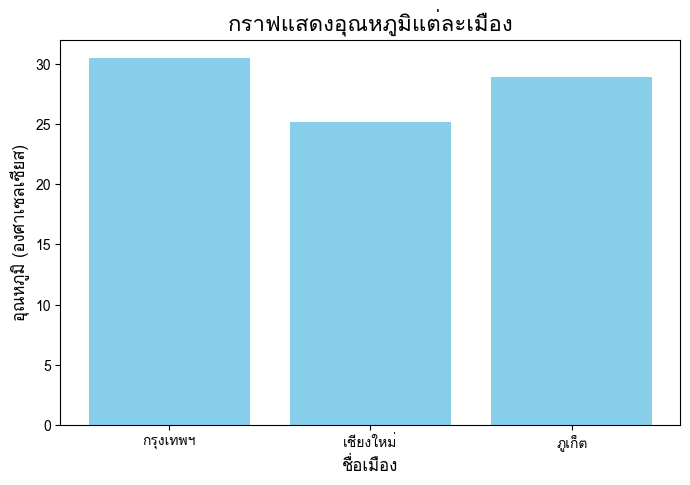

In [121]:
import pandas as pd
import numpy as np
import os, shutil
import matplotlib
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm
import seaborn as sns

# 1. ติดตั้งฟอนต์ภาษาไทย
!apt-get -y install fonts-thai-tlwg

# 2. ล้าง cache ของ matplotlib เพื่ออัปเดตฟอนต์ใหม่
cache_dir = matplotlib.get_cachedir()
if os.path.exists(cache_dir):
    shutil.rmtree(cache_dir)

# 3. ลงทะเบียนฟอนต์ใหม่เข้ากับ FontManager
font_path = '/usr/share/fonts/truetype/tlwg/Loma.ttf'
if os.path.exists(font_path):
    fm.fontManager.addfont(font_path)

# 4. ตั้งค่าฟอนต์หลัก
plt.rcParams['font.family'] = 'Loma'
plt.rcParams['axes.unicode_minus'] = False

# 5. สร้างข้อมูลจำลองและแสดงผล
data = {
    'เมือง': ['กรุงเทพฯ', 'เชียงใหม่', 'ภูเก็ต'],
    'อุณหภูมิ': [30.5, 25.2, 28.9]
}
df_thai = pd.DataFrame(data)

print("ตั้งค่าระบบฟอนต์ภาษาไทยสำเร็จ!")

plt.figure(figsize=(8, 5))
plt.bar(df_thai['เมือง'], df_thai['อุณหภูมิ'], color='skyblue')
plt.title('กราฟแสดงอุณหภูมิแต่ละเมือง', fontsize=16)
plt.xlabel('ชื่อเมือง', fontsize=12)
plt.ylabel('อุณหภูมิ (องศาเซลเซียส)', fontsize=12)
plt.show()

In [122]:
import pandas as pd
import numpy as np

BASE = ("https://raw.githubusercontent.com/PitchayaW/"
        "SC-612-104-Essential-Data-Science/refs/heads/main/Module-A-Notebooks/Dataset/")

df = pd.read_csv(BASE + "world_weather_sample.csv")
city_info = pd.read_csv(BASE + "city_info.csv")
region_info = pd.read_csv(BASE + "region_info.csv")

print("weather:", df.shape, " city_info:", city_info.shape, " region_info:", region_info.shape)
df.head()

weather: (2075, 10)  city_info: (23, 5)  region_info: (6, 3)


,record_id,date,city,country,region,temperature_c,humidity_pct,rainfall_mm,wind_speed_kmh,pressure_hpa
0,983,2025-03-24,New York,USA,North America,15.7,72.6,6.3,15.9,1005.4
1,220,2025-02-09,Tokyo,Japan,Asia,18.3,60.6,0.0,20.5,1015.1
2,1022,2025-02-01,Los Angeles,USA,North America,20.6,46.8,1.2,8.6,1013.5
3,469,2025-01-19,Mumbai,India,Asia,31.0,73.4,8.0,11.8,1000.1
4,1834,2025-02-03,Cape Town,South Africa,Africa,19.1,55.0,0.0,16.6,1015.1


---
## ข้อ 1 การเปรียบเทียบคำสั่งที่มีลักษณะใกล้เคียงกัน

**คำสั่ง:** ให้นักศึกษารันเซลล์โค้ดทั้ง 6 เซลล์ต่อไปนี้ สังเกตผลลัพธ์ที่ได้ แล้วอธิบายกับตนเองให้เข้าใจความแตกต่างของคำสั่งในแต่ละเซลล์ พร้อมระบุว่าในทางปฏิบัติควรเลือกใช้คำสั่งใดในสถานการณ์ใด

การอธิบายควรครอบคลุมทั้ง **ชนิดของผลลัพธ์** **รูปร่างของผลลัพธ์** และ **ความหมายของค่าที่ได้**

In [123]:
# เซลล์ 1.1
s = pd.Series([10, 20, 30], index=["a", "b", "c"])
print(s["a"])
print(s.iloc[0])
print(s[["a", "c"]])

10
10
a    10
c    30
dtype: int64


In [124]:
# เซลล์ 1.2
print(type(df["city"]), df["city"].shape)
print(type(df[["city"]]), df[["city"]].shape)

<class 'pandas.core.series.Series'> (2075,)
<class 'pandas.core.frame.DataFrame'> (2075, 1)


In [125]:
# เซลล์ 1.3
print(df.loc[0:3].shape)
print(df.iloc[0:3].shape)

(4, 10)
(3, 10)


In [126]:
# เซลล์ 1.4
print(df.groupby("city")["temperature_c"].count().head(3))
print(df.groupby("city").size().head(3))

city
Auckland    90
Bangkok     91
Beijing     89
Name: temperature_c, dtype: int64
city
Auckland    90
Bangkok     91
Beijing     90
dtype: int64


In [127]:
# เซลล์ 1.5
print(df.groupby("city")["temperature_c"].mean().head(3))
print(df.groupby("city")[["temperature_c"]].mean().head(3))

city
Auckland    17.804444
Bangkok     32.453846
Beijing     15.598876
Name: temperature_c, dtype: float64
          temperature_c
city                   
Auckland      17.804444
Bangkok       32.453846
Beijing       15.598876


In [128]:
# เซลล์ 1.6
a = pd.Series([1, 2, 3], index=["x", "y", "z"])
b = pd.Series([10, 20, 30], index=["z", "y", "x"])
print(a + b)
print(a.to_numpy() + b.to_numpy())

x    31
y    22
z    13
dtype: int64
[11 22 33]


1.1  s["a"] และ s.iloc[0] ได้ค่าเดียวคือ 10 ส่วน s[["a","c"]] ได้ผลเป็น Series 2 ค่า (10 และ 30) ใส่ชื่อเดียวได้ค่าเดียว ใส่เป็น list ได้ Series

1.2  df["city"] ได้ Series ขนาด (2075,) ส่วน df[["city"]] ได้ DataFrame ขนาด (2075, 1) สรุป: วงเล็บชั้นเดียวได้คอลัมน์แบบ Series สองชั้นได้ตาราง

1.3  loc[0:3] ได้ 4 แถว เพราะรวมแถวสุดท้าย ส่วน iloc[0:3] ได้ 3 แถว เพราะไม่รวมแถวสุดท้าย

1.4  count นับเฉพาะช่องที่มีค่า ส่วน size นับทุกแถวรวมช่องว่าง เช่น Beijing count ได้ 89 แต่ size ได้ 90

1.5  ตัวเลขเท่ากันทั้งสองแบบ ต่างกันที่รูปแบบ [col] ได้ Series ส่วน [[col]] ได้ DataFrame (มีหัวคอลัมน์)

1.6  a + b ของ pandas จับคู่ตามชื่อ index ได้ x=31, y=22, z=13 ส่วน NumPy บวกตามตำแหน่งได้ [11, 22, 33]

อยากเลือกตามชื่อ ใช้ loc อยากเลือกตามลำดับที่ ใช้ iloc / อยากรู้จำนวนค่าที่วัดได้ ใช้ count อยากรู้จำนวนแถว ใช้ size


---
## ข้อ 2 Series และ DataFrame

### ตัวอย่าง

In [129]:
# การสร้าง DataFrame จากโครงสร้างข้อมูลสองรูปแบบ
d1 = pd.DataFrame({"city": ["Bangkok", "Tokyo"], "temp": [30.5, 16.2]})
d2 = pd.DataFrame([{"city": "Bangkok", "temp": 30.5}, {"city": "Tokyo", "temp": 16.2}])
print(d1.equals(d2))

# การเข้าถึงองค์ประกอบของ DataFrame
print(df.columns.tolist())
print(df.index[:5].tolist())
print(df["temperature_c"].nlargest(3).tolist())

True
['record_id', 'date', 'city', 'country', 'region', 'temperature_c', 'humidity_pct', 'rainfall_mm', 'wind_speed_kmh', 'pressure_hpa']
[0, 1, 2, 3, 4]
[999.0, 999.0, 999.0]


### โจทย์ 2.1
สร้าง Series ชื่อ `rain_by_city` ซึ่งเก็บปริมาณฝนรวมของแต่ละเมือง โดยกำหนดให้ index เป็นชื่อเมือง จากนั้นตอบคำถามต่อไปนี้ด้วยโปรแกรม

1. เมืองที่มีปริมาณฝนรวมสูงสุด 3 อันดับแรก
2. สัดส่วนปริมาณฝนของแต่ละเมืองเทียบกับปริมาณฝนรวมทั้งหมด แสดงเป็นร้อยละทศนิยม 2 ตำแหน่ง
3. จำนวนเมืองที่มีปริมาณฝนรวมสูงกว่าค่าเฉลี่ยของทุกเมือง

In [130]:
# คำตอบข้อ 2.1
rain_by_city = df.groupby("city")["rainfall_mm"].sum()
print("1) Top 3 เมืองฝนรวมสูงสุด"); print(rain_by_city.nlargest(3))
pct_rain = (rain_by_city / rain_by_city.sum() * 100).round(2)
print("2) สัดส่วนฝน (%)"); print(pct_rain.sort_values(ascending=False))
print("3) จำนวนเมืองที่ฝนรวม > ค่าเฉลี่ยของทุกเมือง:", (rain_by_city > rain_by_city.mean()).sum(),
      "| ค่าเฉลี่ย =", round(rain_by_city.mean(), 2))


1) Top 3 เมืองฝนรวมสูงสุด
city
Singapore    870.4
Bangkok      685.6
Lagos        652.8
Name: rainfall_mm, dtype: float64
2) สัดส่วนฝน (%)
city
Singapore       10.43
Bangkok          8.21
Lagos            7.82
Mumbai           5.84
Chiang Mai       5.22
Sao Paulo        5.07
Nairobi          4.74
Tokyo            4.61
Auckland         4.22
Paris            3.99
Sydney           3.97
Toronto          3.81
New York         3.78
Mexico City      3.66
Buenos Aires     3.65
London           3.27
Berlin           3.21
Beijing          3.00
Moscow           2.96
Cape Town        2.87
Lima             2.16
Los Angeles      2.03
Cairo            1.47
Name: rainfall_mm, dtype: float64
3) จำนวนเมืองที่ฝนรวม > ค่าเฉลี่ยของทุกเมือง: 8 | ค่าเฉลี่ย = 362.97


คำตอบ

•	1) Singapore (870.4), Bangkok (685.6), Lagos (652.8)

•	2) Singapore 10.43%, Bangkok 8.21%, Lagos 7.82% … Cairo ต่ำสุด 1.47% (รวมทุกเมือง = 100%)

•	3) 8 เมืองที่ฝนรวมสูงกว่าค่าเฉลี่ย (362.97 mm)


### โจทย์ 2.2
สร้าง DataFrame ชื่อ `city_profile` ที่มีหนึ่งแถวต่อหนึ่งเมือง ประกอบด้วยคอลัมน์
`city`, `country`, `region`, `n_records`, `avg_temp`, `total_rain`
โดยกำหนดให้ใช้ `groupby`

In [131]:
# คำตอบข้อ 2.2
city_profile = (df.groupby("city")
                  .agg(country=("country", "first"), region=("region", "first"),
                       n_records=("city", "size"), avg_temp=("temperature_c", "mean"),
                       total_rain=("rainfall_mm", "sum"))
                  .reset_index())
print(city_profile.round(2).to_string())


            city       country         region  n_records  avg_temp  total_rain
0       Auckland   New Zealand        Oceania         90     17.80       351.9
1        Bangkok      Thailand           Asia         91     32.45       685.6
2        Beijing         China           Asia         90     15.60       250.1
3         Berlin       Germany         Europe         90     12.38       268.4
4   Buenos Aires     Argentina  South America         90     19.17       305.1
5          Cairo         Egypt         Africa         91     26.09       123.0
6      Cape Town  South Africa         Africa         90     30.16       239.3
7     Chiang Mai      Thailand           Asia         91     29.68       435.6
8          Lagos       Nigeria         Africa         90     29.49       652.8
9           Lima          Peru  South America         90     21.49       180.3
10        London            UK         Europe         90     13.49       273.3
11   Los Angeles           USA  North America       

---
## ข้อ 3 การนำเข้าข้อมูลด้วย `read_csv()`

### ตัวอย่าง

In [132]:
# พารามิเตอร์ที่ใช้บ่อย ได้แก่ usecols, nrows, parse_dates, dtype, na_values
preview = pd.read_csv(
    BASE + "world_weather_sample.csv",
    usecols=["city", "date", "temperature_c"],
    parse_dates=["date"],
    nrows=5,
)
print(preview.dtypes)
preview

date             datetime64[ns]
city                     object
temperature_c           float64
dtype: object


,date,city,temperature_c
0,2025-03-24,New York,15.7
1,2025-02-09,Tokyo,18.3
2,2025-02-01,Los Angeles,20.6
3,2025-01-19,Mumbai,31.0
4,2025-02-03,Cape Town,19.1


In [133]:
# การอ่านข้อมูลทีละก้อนด้วย chunksize ซึ่งคืนค่าเป็น iterator
total_rows = 0
for chunk in pd.read_csv(BASE + "world_weather_sample.csv", chunksize=500):
    total_rows += len(chunk)
print("จำนวนแถวรวม:", total_rows)

จำนวนแถวรวม: 2075


### โจทย์ 3.1
เขียนคำสั่ง `pd.read_csv()` เพียงคำสั่งเดียวที่ดำเนินการทุกข้อต่อไปนี้ให้เสร็จสิ้นตั้งแต่ขั้นตอนการนำเข้า

1. อ่านเฉพาะคอลัมน์ `date`, `city`, `region`, `temperature_c`, `humidity_pct`, `rainfall_mm`
2. แปลงคอลัมน์ `date` เป็นชนิด datetime
3. กำหนดให้ค่า `999` และ `-999` ถูกอ่านเป็นค่าว่าง
4. กำหนดชนิดข้อมูลของ `city` และ `region` เป็น `category`
5. กำหนดให้ `city` เป็น index

ให้ตรวจสอบผลด้วย `.dtypes` และ `.info()`

In [134]:
# คำตอบข้อ 3.1
# อ่านข้อมูลด้วย pd.read_csv() คำสั่งเดียว: เลือกคอลัมน์, แปลงวันที่, กำหนดค่าว่าง, กำหนดชนิดข้อมูล และตั้ง index
weather = pd.read_csv(
    BASE + "world_weather_sample.csv",
    usecols=["date", "city", "region", "temperature_c", "humidity_pct", "rainfall_mm"],
    parse_dates=["date"],
    na_values=[999, -999],
    dtype={"city": "category", "region": "category"},
    index_col="city",
)

# ตรวจสอบผลด้วย .dtypes และ .info()
print(weather.dtypes)
weather.info()

date             datetime64[ns]
region                 category
temperature_c           float64
humidity_pct            float64
rainfall_mm             float64
dtype: object
<class 'pandas.core.frame.DataFrame'>
CategoricalIndex: 2075 entries, New York to Paris
Data columns (total 5 columns):
 #   Column         Non-Null Count  Dtype         
---  ------         --------------  -----         
 0   date           2075 non-null   datetime64[ns]
 1   region         2075 non-null   category      
 2   temperature_c  2052 non-null   float64       
 3   humidity_pct   1993 non-null   float64       
 4   rainfall_mm    2013 non-null   float64       
dtypes: category(1), datetime64[ns](1), float64(3)
memory usage: 69.8 KB


### โจทย์ 3.2
เปรียบเทียบปริมาณหน่วยความจำที่ใช้ระหว่างตารางที่นำเข้าตามปกติกับตารางจากโจทย์ 3.1 ด้วย `.memory_usage(deep=True)`
รายงานผลเป็นร้อยละที่ลดลง และ **อธิบาย** ว่าคอลัมน์ใดมีผลต่อการลดลงมากที่สุด เพราะเหตุใด

In [135]:
# คำตอบข้อ 3.2
# ตารางแบบนำเข้าปกติ (ไม่กำหนด dtype และ index)
normal = pd.read_csv(
    BASE + "world_weather_sample.csv",
    usecols=["date", "city", "region", "temperature_c", "humidity_pct", "rainfall_mm"],
    parse_dates=["date"],
    na_values=[999, -999],
)

# เปรียบเทียบหน่วยความจำของแต่ละคอลัมน์ (deep=True นับหน่วยความจำของ object จริง)
mem_normal = normal.memory_usage(deep=True)
mem_opt = weather.memory_usage(deep=True)
print(mem_normal)
print(mem_opt)

# ร้อยละที่ลดลงโดยรวม
print("ลดลงรวม (%):", round((1 - mem_opt.sum() / mem_normal.sum()) * 100, 2))

# ร้อยละที่ลดลงรายคอลัมน์ (city อยู่ใน index จึงเทียบแยก)
print("city ลดลง (%):", round((1 - mem_opt["Index"] / mem_normal["city"]) * 100, 2))
print("region ลดลง (%):", round((1 - mem_opt["region"] / mem_normal["region"]) * 100, 2))

Index               132
date              16600
city             116920
region           117631
temperature_c     16600
humidity_pct      16600
rainfall_mm       16600
dtype: int64
Index             3927
date             16600
region            2590
temperature_c    16600
humidity_pct     16600
rainfall_mm      16600
dtype: int64
ลดลงรวม (%): 75.78
city ลดลง (%): 96.64
region ลดลง (%): 97.8


### โจทย์ 3.3
ใช้การอ่านข้อมูลแบบ `chunksize` เพื่อคำนวณค่าต่อไปนี้ โดยห้ามโหลดข้อมูลทั้งไฟล์เข้าหน่วยความจำพร้อมกัน และห้ามใช้ `pd.concat`

1. อุณหภูมิสูงสุดและต่ำสุดของทั้งไฟล์
2. อุณหภูมิเฉลี่ยรายเมือง

**อธิบาย:** เหตุใดการนำค่าเฉลี่ยของแต่ละก้อนมาเฉลี่ยกันอีกครั้งจึงให้ผลไม่ถูกต้อง และควรสะสมค่าใดแทนจึงจะได้ผลที่ถูกต้อง

In [136]:
# คำตอบข้อ 3.3
total_rows = 0
tmax = None
tmin = None
city_sum = {}     # ผลรวมอุณหภูมิรายเมือง
city_count = {}   # จำนวนแถวที่ไม่ใช่ NaN รายเมือง

for chunk in pd.read_csv(
    BASE + "world_weather_sample.csv",
    usecols=["city", "temperature_c"],
    na_values=[999, -999],
    chunksize=500,
):
    # 1. อุณหภูมิสูงสุด/ต่ำสุดของทั้งไฟล์ (เก็บค่าที่ดีที่สุดสะสมไปทีละก้อน)
    c_max, c_min = chunk["temperature_c"].max(), chunk["temperature_c"].min()
    tmax = c_max if tmax is None else max(tmax, c_max)
    tmin = c_min if tmin is None else min(tmin, c_min)

    # 2. สะสมผลรวมและจำนวนแถวรายเมือง
    g = chunk.groupby("city")["temperature_c"].agg(["sum", "count"])
    for city, row in g.iterrows():
        city_sum[city] = city_sum.get(city, 0) + row["sum"]
        city_count[city] = city_count.get(city, 0) + row["count"]

print("อุณหภูมิสูงสุด:", tmax)
print("อุณหภูมิต่ำสุด:", tmin)

avg_by_city = pd.Series(city_sum) / pd.Series(city_count)
print(avg_by_city.round(2))

อุณหภูมิสูงสุด: 39.2
อุณหภูมิต่ำสุด: -88.0
Auckland        17.80
Bangkok         32.45
Beijing         15.60
Berlin          12.38
Buenos Aires    19.17
Cairo           26.09
Cape Town       19.15
Chiang Mai      29.68
Lagos           29.49
Lima            21.49
London          13.49
Los Angeles     20.66
Mexico City     19.19
Moscow           7.23
Mumbai          30.87
Nairobi         21.44
New York        15.48
Paris           14.75
Sao Paulo       22.84
Singapore       29.31
Sydney          20.35
Tokyo           18.41
Toronto         11.61
dtype: float64


---
## ข้อ 4 การสำรวจข้อมูลและการตรวจสอบคุณภาพข้อมูล

### ตัวอย่าง

In [137]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2075 entries, 0 to 2074
Data columns (total 10 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   record_id       2075 non-null   int64  
 1   date            2075 non-null   object 
 2   city            2075 non-null   object 
 3   country         2075 non-null   object 
 4   region          2075 non-null   object 
 5   temperature_c   2055 non-null   float64
 6   humidity_pct    1993 non-null   float64
 7   rainfall_mm     2013 non-null   float64
 8   wind_speed_kmh  2034 non-null   float64
 9   pressure_hpa    2043 non-null   float64
dtypes: float64(5), int64(1), object(4)
memory usage: 162.2+ KB


In [138]:
print(df.describe().round(2))
print(df.describe(include="all").iloc[:4])

       record_id  temperature_c  humidity_pct  rainfall_mm  wind_speed_kmh  \
count    2075.00        2055.00       1993.00      2013.00         2034.00   
mean     1035.15          21.84         66.82         4.15           14.78   
std       598.02          38.22         13.09         3.85            5.88   
min         1.00         -88.00         21.50         0.00           -5.00   
25%       517.50          15.40         58.60         0.30           10.80   
50%      1035.00          20.00         67.10         3.50           15.00   
75%      1553.50          25.70         75.50         6.60           18.70   
max      2070.00         999.00        150.00        17.60           33.70   

       pressure_hpa  
count       2043.00  
mean        1013.13  
std            5.86  
min          993.90  
25%         1009.30  
50%         1013.10  
75%         1017.20  
max         1030.60  
        record_id        date        city   country region  temperature_c  \
count      2075.0     

In [139]:
print(df.isna().sum())
print("จำนวนแถวที่มีค่าว่างอย่างน้อยหนึ่งคอลัมน์:", df.isna().any(axis=1).sum())
print("จำนวนแถวที่ซ้ำกันทุกคอลัมน์:", df.duplicated().sum())

record_id          0
date               0
city               0
country            0
region             0
temperature_c     20
humidity_pct      82
rainfall_mm       62
wind_speed_kmh    41
pressure_hpa      32
dtype: int64
จำนวนแถวที่มีค่าว่างอย่างน้อยหนึ่งคอลัมน์: 229
จำนวนแถวที่ซ้ำกันทุกคอลัมน์: 5


### โจทย์ 4.1
สร้าง DataFrame ชื่อ `summary` ที่มีหนึ่งแถวต่อหนึ่งคอลัมน์ของ `df` ประกอบด้วย
`dtype`, `n_missing`, `pct_missing`, `n_unique`, `example_value`
โดยห้ามใช้การวนซ้ำทีละคอลัมน์ และให้เรียงลำดับจากคอลัมน์ที่มีค่าว่างมากที่สุด

In [140]:
# คำตอบข้อ 4.1
summary = pd.DataFrame({
    "dtype": df.dtypes.astype(str),
    "n_missing": df.isna().sum(),
    "n_unique": df.nunique(),
    "example_value": df.bfill().iloc[0],          # ค่าแรกที่ไม่ว่างของแต่ละคอลัมน์
})
summary["pct_missing"] = (summary["n_missing"] / len(df) * 100).round(2)
summary = summary[["dtype", "n_missing", "pct_missing", "n_unique", "example_value"]] \
          .sort_values("n_missing", ascending=False)
print(summary.to_string())


                  dtype  n_missing  pct_missing  n_unique  example_value
humidity_pct    float64         82         3.95       544           72.6
rainfall_mm     float64         62         2.99       164            6.3
wind_speed_kmh  float64         41         1.98       278           15.9
pressure_hpa    float64         32         1.54       294         1005.4
temperature_c   float64         20         0.96       331           15.7
record_id         int64          0         0.00      2070            983
date             object          0         0.00        90     2025-03-24
region           object          0         0.00         6  North America
city             object          0         0.00        23       New York
country          object          0         0.00        28            USA


### โจทย์ 4.2
ผลลัพธ์ของ `.describe()` แสดงค่าสูงสุดของ `temperature_c` และ `humidity_pct` ที่เป็นไปไม่ได้ในทางกายภาพ ให้เขียนโปรแกรมหาค่าต่อไปนี้

1. จำนวนแถวที่ `temperature_c` อยู่นอกช่วง -60 ถึง 60
2. จำนวนแถวที่ `humidity_pct` อยู่นอกช่วง 0 ถึง 100
3. จำนวนแถวที่มีความผิดปกติอย่างน้อยหนึ่งคอลัมน์ โดยระวังการนับซ้ำ

In [141]:
# คำตอบข้อ 4.2
bad_t = (df["temperature_c"] < -60) | (df["temperature_c"] > 60)
bad_h = (df["humidity_pct"] < 0) | (df["humidity_pct"] > 100)
print("1) temp นอก [-60,60]:", bad_t.sum(), " ค่าที่พบ:", sorted(df.loc[bad_t, "temperature_c"].unique()))
print("2) humidity นอก [0,100]:", bad_h.sum(), " ค่าที่พบ:", sorted(df.loc[bad_h, "humidity_pct"].unique()))
print("3) ผิดปกติอย่างน้อย 1 คอลัมน์ (OR):", (bad_t | bad_h).sum(),
      "| แถวที่ผิดทั้งคู่ (ซ้อนกัน):", (bad_t & bad_h).sum(),
      "| ผลบวกตรง ๆ:", bad_t.sum() + bad_h.sum())


1) temp นอก [-60,60]: 5  ค่าที่พบ: [np.float64(-88.0), np.float64(999.0)]
2) humidity นอก [0,100]: 3  ค่าที่พบ: [np.float64(150.0)]
3) ผิดปกติอย่างน้อย 1 คอลัมน์ (OR): 8 | แถวที่ผิดทั้งคู่ (ซ้อนกัน): 0 | ผลบวกตรง ๆ: 8


### โจทย์ 4.3
คอลัมน์ `country` มีจำนวนค่าไม่ซ้ำมากกว่าจำนวนประเทศที่มีอยู่จริง เนื่องจากการใช้ตัวพิมพ์ไม่สม่ำเสมอ

1. แสดงว่าค่าใดบ้างที่หมายถึงประเทศเดียวกันแต่ถูกนับแยกจากกัน
2. ทดลองใช้ `df["country"].str.title()` แล้ว **อธิบาย** ว่าวิธีนี้ทำให้ข้อมูลของประเทศใดเสียหาย และเพราะเหตุใด
3. เสนอและเขียนวิธี normalize ที่ถูกต้อง โดยต้องรองรับกรณีที่มีช่องว่างหัวท้ายด้วย

> **การตรวจสอบคำตอบ:** จำนวนประเทศที่ถูกต้องคือ 21 ประเทศ จากทั้งหมด 23 เมือง

In [142]:
# คำตอบข้อ 4.3
key = df["country"].str.strip().str.lower()
variants = (df.assign(key=key).groupby("key")["country"].unique()
              .loc[lambda x: x.str.len() > 1])
print("นับดิบ:", df["country"].nunique(), "ค่า | หลัง lower/strip:", key.nunique())
print(variants)
t = df["country"].str.title()
print("title() ->", t.nunique(), "ค่า; ที่เสียหาย:",
      sorted(set(t[df["country"].isin(["UK", "USA"])])))
canon = {c.upper(): c for c in city_info["country"].unique()}   # ชื่อมาตรฐานจาก city_info
country_clean = df["country"].str.strip().str.upper().map(canon)
print("normalize:", country_clean.nunique(), "ประเทศ | map ไม่ได้:", country_clean.isna().sum())
print("จำนวนเมือง:", df["city"].nunique())


นับดิบ: 28 ค่า | หลัง lower/strip: 21
key
argentina          [Argentina, ARGENTINA]
canada                   [Canada, CANADA]
germany                [Germany, GERMANY]
japan                      [Japan, JAPAN]
kenya                      [Kenya, KENYA]
new zealand    [New Zealand, NEW ZEALAND]
singapore          [Singapore, SINGAPORE]
Name: country, dtype: object
title() -> 21 ค่า; ที่เสียหาย: ['Uk', 'Usa']
normalize: 21 ประเทศ | map ไม่ได้: 0
จำนวนเมือง: 23


---
## ข้อ 5 การเลือกข้อมูลด้วย `loc` และ `iloc`

### ตัวอย่าง

In [143]:
# iloc อ้างอิงตามตำแหน่ง ส่วน loc อ้างอิงตาม label และรวมค่าปลายช่วง
print(df.iloc[0:3, 0:3].shape, df.loc[0:3, ["city", "region"]].shape)

# loc ใช้ร่วมกับเงื่อนไขและเลือกคอลัมน์ได้ในคำสั่งเดียว
print(df.loc[df["temperature_c"] > 35, ["city", "date", "temperature_c"]].head(3))

(3, 3) (4, 2)
          city        date  temperature_c
78   Cape Town  2025-02-10          999.0
161    Bangkok  2025-02-14           38.6
325     Mumbai  2025-03-31           35.6


In [144]:
# การกำหนด index หลายระดับ และการเลือกข้อมูลจาก index หลายระดับ
multi = df.set_index(["region", "city"]).sort_index()
print(multi.loc["Asia"].shape)
print(multi.loc[("Asia", "Tokyo"), ["date", "temperature_c"]].head(3))

(542, 8)
                    date  temperature_c
region city                            
Asia   Tokyo  2025-02-09           18.3
       Tokyo  2025-03-21           19.7
       Tokyo  2025-03-23           17.7


### โจทย์ 5.1
ใช้ `.iloc[]` เท่านั้น โดยห้ามอ้างอิงชื่อคอลัมน์ เพื่อดึงข้อมูลต่อไปนี้

1. แถวที่อยู่ในตำแหน่งเลขคู่ 10 แถวแรก เฉพาะสามคอลัมน์สุดท้าย
2. ห้าแถวสุดท้าย โดยเรียงลำดับจากแถวล่างสุดขึ้นไป
3. ค่าเดี่ยวที่อยู่ในแถวกึ่งกลางตารางและคอลัมน์สุดท้าย โดยต้องคำนวณตำแหน่งกึ่งกลางจากจำนวนแถว

In [145]:
# คำตอบข้อ 5.1
print(df.iloc[0:20:2, -3:])
print(df.iloc[-1:-6:-1])
mid = len(df) // 2
print("แถวกลาง position", mid, "ค่า =", df.iloc[mid, -1])


    rainfall_mm  wind_speed_kmh  pressure_hpa
0           6.3            15.9        1005.4
2           1.2             8.6        1013.5
4           0.0            16.6        1015.1
6           2.7            14.6        1018.0
8           1.6             9.8        1007.7
10          0.0            15.6        1010.1
12          0.0            13.6        1015.8
14          2.2            24.6        1000.5
16          8.3             9.3        1019.4
18          8.9            23.3        1020.6
      record_id        date         city country         region  \
2074        642  2025-01-12        Paris  France         Europe   
2073       1210  2025-02-09      Toronto  Canada  North America   
2072       1738  2025-01-28      Nairobi   Kenya         Africa   
2071       1769  2025-02-28      Nairobi   Kenya         Africa   
2070       1093  2025-01-13  Mexico City  Mexico  North America   

      temperature_c  humidity_pct  rainfall_mm  wind_speed_kmh  pressure_hpa  
2074        

### โจทย์ 5.2
จาก DataFrame ที่กำหนด index เป็นคู่ `(region, city)` ให้ดึงข้อมูลต่อไปนี้ด้วย `.loc[]`

1. ข้อมูลทั้งหมดของภูมิภาค Asia เฉพาะคอลัมน์ `date` และ `temperature_c`
2. ข้อมูลของเมือง Tokyo และ Bangkok พร้อมกันในคำสั่งเดียว
3. ข้อมูลของทุกภูมิภาค แต่เฉพาะเมืองที่ชื่อขึ้นต้นด้วยตัวอักษร B

**อธิบาย:** เหตุใดจึงควรเรียงลำดับ index ด้วย `.sort_index()` ก่อนใช้งาน index หลายระดับ

In [146]:
# คำตอบข้อ 5.2
multi = df.set_index(["region", "city"]).sort_index()
asia = multi.loc["Asia", ["date", "temperature_c"]]
print(asia.shape); print(asia.head(3))
print(multi.loc[(slice(None), ["Tokyo", "Bangkok"]), :].shape)
mask_b = multi.index.get_level_values("city").str.startswith("B")
print(multi.loc[mask_b].index.get_level_values("city").unique().tolist())


(542, 2)
               date  temperature_c
city                              
Bangkok  2025-02-22           30.8
Bangkok  2025-01-10           28.9
Bangkok  2025-01-27           27.9
(181, 8)
['Bangkok', 'Beijing', 'Berlin', 'Buenos Aires']


MultiIndex ที่เรียงแล้วทำให้ pandas ค้นหาและ slice ตามช่วงได้ถูกต้องและเร็ว ถ้าไม่เรียงจะเกิด UnsortedIndexError หรือ PerformanceWarning และบางกรณีได้ผลไม่ตรงที่ตั้งใจ

### โจทย์ 5.3
ให้รันโปรแกรมต่อไปนี้ แล้วสังเกตผลที่เกิดขึ้นกับ `df`

```python
subset = df[df["city"] == "Bangkok"]
subset["temperature_c"] = 0
```

จากนั้นเขียนโปรแกรมที่ถูกต้องสองรูปแบบ ได้แก่ รูปแบบที่ต้องการแก้ไข `df` จริง และรูปแบบที่ต้องการทำงานกับสำเนาแยกต่างหาก
พร้อมสรุปเป็นแนวปฏิบัติของตนเองความยาว 2 ถึง 3 บรรทัด

In [147]:
subset = df[df["city"] == "Bangkok"]
subset["temperature_c"] = 0

/tmp/ipykernel_4057/427233649.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  subset["temperature_c"] = 0


In [148]:
# คำตอบข้อ 5.3
d0 = df.copy()
subset = d0[d0["city"] == "Bangkok"]
try:
    subset["temperature_c"] = 0
except Exception as e:
    print("error:", e)
print("d0 Bangkok temp ไม่เปลี่ยน?", d0.loc[d0.city == "Bangkok", "temperature_c"].head(3).tolist())
d1 = df.copy()
d1.loc[d1["city"] == "Bangkok", "temperature_c"] = 0                 # แก้ df จริง
print("แก้จริง:", d1.loc[d1.city == "Bangkok", "temperature_c"].unique())
sub_copy = df[df["city"] == "Bangkok"].copy()
sub_copy["temperature_c"] = 0                                         # สำเนาแยก
print("สำเนา:", sub_copy["temperature_c"].unique(), "| df เดิม:", df.loc[df.city == "Bangkok", "temperature_c"].head(2).tolist())


d0 Bangkok temp ไม่เปลี่ยน? [30.8, 28.9, 27.9]
แก้จริง: [0.]
สำเนา: [0] | df เดิม: [30.8, 28.9]


/tmp/ipykernel_4057/245165410.py:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  subset["temperature_c"] = 0


สรุปแนวทางปฏิบัติ

เมื่อต้องการแก้ค่าใน df จริง ให้ใช้ df.loc[เงื่อนไข, "คอลัมน์"] = ค่า ในคำสั่งเดียว ห้ามกรองเป็น subset = df[...] ก่อนแล้วค่อยแก้ subset[...] เพราะ pandas อาจให้สำเนาแทน view ทำให้ df ไม่เปลี่ยนและเกิด SettingWithCopyWarning แต่ถ้าต้องการทำงานกับสำเนาแยกโดยไม่กระทบ df ให้เขียน .copy() ต่อท้ายตอนกรอง (sub = df[df["city"] == "Bangkok"].copy()) เพื่อประกาศเจตนาให้ชัดและไม่มี warning

---
## ข้อ 6 การกรองข้อมูลด้วยเงื่อนไข

### ตัวอย่าง

In [149]:
# การใช้ตัวดำเนินการ & | ~ ต้องครอบวงเล็บทุกเงื่อนไข
print(len(df[(df["temperature_c"] > 28) & (df["humidity_pct"] > 70)]))
print(len(df[~df["city"].isin(["Bangkok", "Tokyo"])]))
print(len(df[df["temperature_c"].between(20, 30)]))
print(len(df.query("region == 'Asia' and rainfall_mm > 5")))

237
1894
757
295


In [150]:
# where และ mask ไม่ลดจำนวนแถว แต่แทนค่าที่ไม่ตรงเงื่อนไขด้วยค่าที่กำหนด
temp_valid = df["temperature_c"].where(df["temperature_c"].between(-60, 60))
rain_capped = df["rainfall_mm"].mask(df["rainfall_mm"] > 15, 15)
print(temp_valid.isna().sum(), df["temperature_c"].isna().sum())
print(rain_capped.max(), df["rainfall_mm"].max())

25 20
15.0 17.6


In [151]:
# pipe ใช้ต่อขั้นตอนการประมวลผลหลายขั้นให้เป็นลำดับเดียว
def add_flag(data, threshold):
    return data.assign(is_hot=data["temperature_c"] > threshold)

result = (df
          .query("region == 'Asia'")
          .pipe(add_flag, threshold=30)
          .loc[:, ["city", "temperature_c", "is_hot"]])
print(result.head(3))

       city  temperature_c  is_hot
1     Tokyo           18.3   False
3    Mumbai           31.0    True
12  Beijing           14.3   False


### โจทย์ 6.1
เขียนเงื่อนไขสำหรับกรองข้อมูลต่อไปนี้

1. ข้อมูลในภูมิภาคเอเชียที่ปริมาณฝนมากกว่า 5 มิลลิเมตร และความเร็วลมมากกว่า 20 กิโลเมตรต่อชั่วโมง
2. ข้อมูลที่ไม่ใช่เมือง Bangkok, Tokyo และ London และมีความชื้นระหว่าง 40 ถึง 60
3. แถวที่มีค่าว่างตั้งแต่ 2 คอลัมน์ขึ้นไป
4. แถวที่ชื่อเมืองมีคำว่า New หรือ San ประกอบอยู่ โดยใช้ `.str.contains` ร่วมกับ regular expression

In [152]:
# คำตอบข้อ 6.1
r1 = df[(df["region"] == "Asia") & (df["rainfall_mm"] > 5) & (df["wind_speed_kmh"] > 20)]
r2 = df[~df["city"].isin(["Bangkok", "Tokyo", "London"]) & df["humidity_pct"].between(40, 60)]
r3 = df[df.isna().sum(axis=1) >= 2]
r4 = df[df["city"].str.contains(r"\b(?:New|San)\b", regex=True, na=False)]
print(len(r1), len(r2), len(r3), len(r4), r4["city"].unique())


54 470 8 90 ['New York']


คำตอบ

1) 54 แถว  

2) 470 แถว  

3) 8 แถว  

4) 90 แถว (เป็น New York เมืองเดียว)

### โจทย์ 6.2
ใช้ `.where()` และ `.mask()` สร้างคอลัมน์ใหม่สองคอลัมน์ ได้แก่ คอลัมน์อุณหภูมิที่แทนค่าผิดปกติด้วยค่าว่าง และคอลัมน์ปริมาณฝนที่จำกัดค่าสูงสุดไว้ที่ค่าเปอร์เซ็นไทล์ที่ 99
**อธิบาย:** แนวทางนี้แตกต่างจากการลบแถวทิ้งอย่างไรในแง่ของการวิเคราะห์ในขั้นถัดไป

In [153]:
# คำตอบข้อ 6.2
p99 = df["rainfall_mm"].quantile(0.99)
df = df.assign(
    temp_clean=df["temperature_c"].where(df["temperature_c"].between(-60, 60)),
    rain_cap=df["rainfall_mm"].mask(df["rainfall_mm"] > p99, p99),
)
print("p99 =", p99, "| ฝนสูงสุดเดิม", df["rainfall_mm"].max(), "-> หลังจำกัด", df["rain_cap"].max())
print("จำนวนแถว:", len(df), "| NaN temp:", df["temperature_c"].isna().sum(), "->", df["temp_clean"].isna().sum())


p99 = 14.687999999999988 | ฝนสูงสุดเดิม 17.6 -> หลังจำกัด 14.687999999999988
จำนวนแถว: 2075 | NaN temp: 20 -> 25


คำตอบ

การลบแถวทำให้สูญเสียข้อมูลคอลัมน์อื่นที่ถูกต้องของแถวเดียวกัน และทำให้จำนวนวัน/เมืองไม่ครบ กระทบอนุกรมเวลาและการรวมตาราง ส่วน where/mask คงรูปร่างตารางเดิมไว้ ค่าที่ผิดกลายเป็น NaN ซึ่ง mean/count ข้ามให้อัตโนมัติ และยังเลือกวิธีเติมค่าภายหลังได้ การจำกัดที่ p99 คงข้อมูลว่า "ฝนหนักมาก" ไว้ แต่ไม่ให้ค่าสุดโต่งดึงค่าเฉลี่ยมากเกินไป

### โจทย์ 6.3
หาวันที่มีอุณหภูมิห่างจากค่าเฉลี่ยของเมืองตนเองมากที่สุดของแต่ละเมือง
ผลลัพธ์ต้องมีหนึ่งแถวต่อหนึ่งเมือง ประกอบด้วยคอลัมน์ `city`, `date`, `temperature_c`, `deviation`

In [154]:
# คำตอบข้อ 6.3
dev = (df["temp_clean"] - df.groupby("city")["temp_clean"].transform("mean"))
idx = dev.abs().groupby(df["city"]).idxmax()
res63 = (df.loc[idx, ["city", "date", "temp_clean"]]
           .rename(columns={"temp_clean": "temperature_c"})
           .assign(deviation=dev.loc[idx].values).reset_index(drop=True))
print(res63.round(2).to_string())


            city        date  temperature_c  deviation
0       Auckland  2025-02-27           25.6       7.80
1        Bangkok  2025-03-26           39.1       6.65
2        Beijing  2025-03-06           22.6       7.00
3         Berlin  2025-03-26           19.4       7.02
4   Buenos Aires  2025-01-02           12.2      -8.19
5          Cairo  2025-03-31           33.6       7.51
6      Cape Town  2025-03-23           25.5       6.35
7     Chiang Mai  2025-03-28           37.3       7.62
8          Lagos  2025-01-01           21.1      -8.39
9           Lima  2025-01-22           12.9      -8.59
10        London  2025-02-09           23.4       9.91
11   Los Angeles  2025-01-09           13.4      -7.26
12   Mexico City  2025-02-24           26.5       7.31
13        Moscow  2025-01-20           -0.2      -7.43
14        Mumbai  2025-01-07           24.2      -6.67
15       Nairobi  2025-03-11           27.8       6.36
16      New York  2025-03-16           24.5       9.02
17        

---
## ข้อ 7 การจัดการข้อมูลวันที่และเวลา

### ตัวอย่าง

In [155]:
df["date"] = pd.to_datetime(df["date"])
print(df["date"].dt.month.head(3).tolist())
print(df["date"].dt.day_name().head(3).tolist())
print(df["date"].min(), df["date"].max())

# assign ใช้สร้างหลายคอลัมน์ในคำสั่งเดียวและคืนค่าเป็น DataFrame ใหม่
tmp = df.assign(
    year_month=df["date"].dt.to_period("M").astype(str),
    is_weekend=df["date"].dt.dayofweek >= 5,
)
print(tmp[["date", "year_month", "is_weekend"]].head(3))

[3, 2, 2]
['Monday', 'Sunday', 'Saturday']
2025-01-01 00:00:00 2025-03-31 00:00:00
        date year_month  is_weekend
0 2025-03-24    2025-03       False
1 2025-02-09    2025-02        True
2 2025-02-01    2025-02        True


In [156]:
# resample สรุปข้อมูลตามช่วงเวลา โดยต้องกำหนด index เป็น datetime ก่อน
bkk = df[df["city"] == "Bangkok"].set_index("date").sort_index()
print(bkk["temperature_c"].resample("7D").mean().head(4).round(2))

date
2025-01-01    30.36
2025-01-08    31.09
2025-01-15    30.39
2025-01-22    32.29
Freq: 7D, Name: temperature_c, dtype: float64


### โจทย์ 7.1
ใช้ `.assign()` เพียงคำสั่งเดียวสร้างคอลัมน์ `year_month`, `week_of_year`, `day_name` และ `is_weekend`

In [157]:
# คำตอบข้อ 7.1
df["date"] = pd.to_datetime(df["date"])
tmp71 = df.assign(
    year_month=df["date"].dt.to_period("M").astype(str),
    week_of_year=df["date"].dt.isocalendar().week,
    day_name=df["date"].dt.day_name(),
    is_weekend=df["date"].dt.dayofweek >= 5,
)
print(tmp71[["date", "year_month", "week_of_year", "day_name", "is_weekend"]].head(4))


        date year_month  week_of_year  day_name  is_weekend
0 2025-03-24    2025-03            13    Monday       False
1 2025-02-09    2025-02             6    Sunday        True
2 2025-02-01    2025-02             5  Saturday        True
3 2025-01-19    2025-01             3    Sunday        True


### โจทย์ 7.2
ตอบคำถามต่อไปนี้ด้วยโปรแกรม

1. ข้อมูลครอบคลุมทั้งหมดกี่วัน และมีวันใดในช่วงดังกล่าวที่ไม่มีข้อมูลเลยหรือไม่ โดยใช้ `pd.date_range` ประกอบการตรวจสอบ
2. อุณหภูมิเฉลี่ยของวันหยุดสุดสัปดาห์เปรียบเทียบกับวันธรรมดา จำแนกตามภูมิภาค
3. เดือนที่มีปริมาณฝนรวมสูงสุดของแต่ละเมือง

In [158]:
# คำตอบข้อ 7.2
full_range = pd.date_range(df["date"].min(), df["date"].max(), freq="D")
missing_days = full_range.difference(pd.DatetimeIndex(df["date"].unique()))
print("1) ครอบคลุม", len(full_range), "วัน; วันที่ไม่มีข้อมูลเลย:", len(missing_days))
wk = (df.assign(is_weekend=df["date"].dt.dayofweek >= 5)
        .groupby(["region", "is_weekend"])["temp_clean"].mean().unstack()
        .rename(columns={False: "weekday", True: "weekend"}))
wk["weekend-weekday"] = wk["weekend"] - wk["weekday"]
print("2)"); print(wk.round(2))
rain_cm = df.groupby(["city", df["date"].dt.month])["rainfall_mm"].sum().unstack()
top_month = rain_cm.idxmax(axis=1).rename("month_max_rain")
print("3)"); print(pd.concat([top_month, rain_cm.max(axis=1).round(1).rename("rain_mm")], axis=1).to_string())
print(top_month.value_counts())


1) ครอบคลุม 90 วัน; วันที่ไม่มีข้อมูลเลย: 0
2)
is_weekend     weekday  weekend  weekend-weekday
region                                          
Africa           24.08    23.88            -0.19
Asia             26.25    26.53             0.28
Europe           11.93    11.95             0.02
North America    16.72    16.84             0.13
Oceania          18.94    19.40             0.46
South America    21.70    21.26            -0.44
3)
              month_max_rain  rain_mm
city                                 
Auckland                   3    150.0
Bangkok                    2    243.9
Beijing                    2     87.4
Berlin                     3    100.1
Buenos Aires               2    121.2
Cairo                      2     48.0
Cape Town                  1     98.3
Chiang Mai                 3    188.0
Lagos                      3    233.0
Lima                       1     88.0
London                     1    117.2
Los Angeles                1     78.6
Mexico City               

คำตอบ

1) ครอบคลุม 90 วัน (1 ม.ค.–31 มี.ค. 2025) ไม่มีวันที่ขาดข้อมูลทั้งวัน

2) วันหยุดต่างจากวันธรรมดาเพียง −0.44 ถึง +0.46 °C (Africa −0.19, Asia +0.28, Europe +0.02, North America +0.13, Oceania +0.46, South America −0.44) ไม่มีรูปแบบชัดเจน

3) เดือนที่ฝนรวมสูงสุดของแต่ละเมืองดูตารางที่โค้ดพิมพ์ (เดือน 1 มี 10 เมือง เดือน 2 มี 7 เมือง เดือน 3 มี 6 เมือง)


### โจทย์ 7.3
ใช้ `.resample()` สรุปข้อมูลของเมือง Bangkok เป็นราย 7 วัน โดยแสดงอุณหภูมิเฉลี่ยและปริมาณฝนรวมในตารางเดียวกัน
**อธิบาย:** `.resample()` แตกต่างจาก `groupby(df["date"].dt.month)` อย่างไร และกรณีใดที่จำเป็นต้องใช้ `.resample()` เท่านั้น

In [159]:
# คำตอบข้อ 7.3
bkk = df[df["city"] == "Bangkok"].set_index("date").sort_index()
w7 = bkk.resample("7D").agg(avg_temp=("temp_clean", "mean"), total_rain=("rainfall_mm", "sum")).round(2)
print(w7)
print("จำนวนแถวของ Bangkok:", len(bkk), "| มีวันซ้ำ:", bkk.index.duplicated().sum())


            avg_temp  total_rain
date                            
2025-01-01     30.36        65.7
2025-01-08     31.09        47.6
2025-01-15     30.39        58.7
2025-01-22     32.29        50.0
2025-01-29     31.76        55.4
2025-02-05     33.03        65.1
2025-02-12     34.21        60.2
2025-02-19     32.30        42.5
2025-02-26     32.34        61.7
2025-03-05     32.99        49.1
2025-03-12     33.04        56.4
2025-03-19     33.16        41.9
2025-03-26     35.40        31.3
จำนวนแถวของ Bangkok: 91 | มีวันซ้ำ: 1


อธิบาย

groupby(เดือน) จัดกลุ่มตามค่าของเดือนซึ่งเป็นหมวดหมู่ ถ้าข้อมูลหลายปี เดือนเดียวกันของทุกปีจะรวมกัน และไม่สร้างกลุ่มให้ช่วงที่ไม่มีข้อมูล ส่วน resample ตัดอนุกรมเวลาเป็นช่วงต่อเนื่องที่ความกว้างคงที่ ตามลำดับเวลา (ต้องมี DatetimeIndex) ต้องใช้ resample เมื่อช่วงเวลาไม่ตรงปฏิทิน เช่น ทุก 7 วัน 10 วัน 15 นาที หรือเมื่อต้องการให้ช่วงที่ไม่มีข้อมูลโผล่เป็นแถวว่าง

---
## ข้อ 8 การจัดการค่าว่างและข้อมูลซ้ำ

### ตัวอย่าง

In [160]:
# การเติมค่าว่างด้วยค่าสถิติของกลุ่มตนเอง โดยใช้ transform
filled_by_city = df["temperature_c"].fillna(
    df.groupby("city")["temperature_c"].transform("mean")
)
print(df["temperature_c"].isna().sum(), "->", filled_by_city.isna().sum())

# การเติมค่าด้วยค่าของวันก่อนหน้าภายในเมืองเดียวกัน
sorted_df = df.sort_values(["city", "date"])
ffilled = sorted_df.groupby("city")["temperature_c"].ffill()
print("หลังเติมแบบ ffill เหลือค่าว่าง:", ffilled.isna().sum())

20 -> 0
หลังเติมแบบ ffill เหลือค่าว่าง: 0


In [161]:
# การตรวจสอบข้อมูลซ้ำตามคีย์ที่กำหนด
print("ซ้ำทุกคอลัมน์:", df.duplicated().sum())
print("ซ้ำตามคีย์ (city, date):", df.duplicated(subset=["city", "date"]).sum())
print("จำนวนแถวหลังขจัดข้อมูลซ้ำ:", df.drop_duplicates().shape[0])

ซ้ำทุกคอลัมน์: 5
ซ้ำตามคีย์ (city, date): 5
จำนวนแถวหลังขจัดข้อมูลซ้ำ: 2070


### โจทย์ 8.1
ตอบคำถามต่อไปนี้ด้วยโปรแกรม

1. คอลัมน์ใดมีค่าว่างมากที่สุด และคิดเป็นร้อยละเท่าใด
2. ค่าว่างกระจายตัวเท่ากันทุกเมืองหรือไม่ ให้สร้างตารางแสดงสัดส่วนค่าว่างของ `temperature_c` จำแนกตามเมือง
3. หากลบทุกแถวที่มีค่าว่างด้วย `dropna()` จะเหลือข้อมูลคิดเป็นร้อยละเท่าใดของข้อมูลเดิม และเมืองใดสูญเสียข้อมูลมากที่สุด

In [162]:
# คำตอบข้อ 8.1
miss = df[["temperature_c", "humidity_pct", "rainfall_mm", "wind_speed_kmh", "pressure_hpa"]].isna()
pct = (miss.mean() * 100).round(2)
print("1)", pct.idxmax(), pct.max(), "%"); print(pct)
miss_city = df["temperature_c"].isna().groupby(df["city"]).agg(["sum", "mean"])
miss_city["mean"] = (miss_city["mean"] * 100).round(2)
print("2)"); print(miss_city.sort_values("sum", ascending=False).head(8).T)
print("cities with 0 missing:", (miss_city["sum"] == 0).sum(), " of ", len(miss_city))
kept = df.dropna()
print("3) เหลือ", len(kept), "แถว =", round(len(kept)/len(df)*100, 2), "% ของเดิม")
loss = (df.groupby("city").size() - kept.groupby("city").size()).rename("rows_lost")
loss_pct = (loss / df.groupby("city").size() * 100).round(1).rename("pct_lost")
print(pd.concat([loss, loss_pct], axis=1).sort_values("rows_lost", ascending=False).head(5))


1) humidity_pct 3.95 %
temperature_c     0.96
humidity_pct      3.95
rainfall_mm       2.99
wind_speed_kmh    1.98
pressure_hpa      1.54
dtype: float64
2)
city  Lagos  London  Cairo  Tokyo  Toronto  Berlin  Beijing  Sao Paulo
sum    3.00    2.00    2.0   2.00     2.00    1.00     1.00       1.00
mean   3.33    2.22    2.2   2.22     2.22    1.11     1.11       1.11
cities with 0 missing: 9  of  23
3) เหลือ 1841 แถว = 88.72 % ของเดิม
          rows_lost  pct_lost
city                         
Auckland         14      15.6
Bangkok          13      14.3
London           13      14.4
Lagos            12      13.3
Tokyo            12      13.3


คำตอบ

1) humidity_pct ว่างมากที่สุด 3.95%

2) ไม่เท่ากันทุกเมือง แต่ต่างกันน้อย: Lagos ว่าง 3 วัน (3.33%) London/Cairo/Tokyo/Toronto เมืองละ 2 วัน และ 9 เมืองไม่ว่างเลย เพราะค่าว่างมีเพียง 20 ค่า

3) dropna() เหลือ 1,841 แถว = 88.72% ของเดิม เมืองที่เสียมากที่สุดคือ Auckland (14 แถว, 15.6%)


### โจทย์ 8.2
เติมค่าว่างของ `temperature_c` ด้วยสามวิธี ได้แก่ ค่าเฉลี่ยรวมทั้งตาราง ค่าเฉลี่ยของเมืองตนเอง และค่าของวันก่อนหน้าภายในเมืองเดียวกัน
จากนั้นเปรียบเทียบผลกระทบต่อค่าเฉลี่ยและส่วนเบี่ยงเบนมาตรฐานรายเมืองในรูปตารางเดียว

**อธิบาย:** วิธีใดเหมาะสมที่สุดกับข้อมูลชุดนี้ และวิธีใดทำให้ความแปรปรวนของข้อมูลลดลงอย่างผิดธรรมชาติ

In [163]:
# คำตอบข้อ 8.2
tt = df["temp_clean"]
srt = df.sort_values(["city", "date"])
fills = {
    "ก่อนเติม": tt,
    "เติมค่าเฉลี่ยรวม": tt.fillna(tt.mean()),
    "เติมค่าเฉลี่ยเมือง": tt.fillna(df.groupby("city")["temp_clean"].transform("mean")),
    "เติมค่าวันก่อนหน้า": srt.groupby("city")["temp_clean"].ffill().reindex(df.index),
}
rows = {}
for name, ser in fills.items():
    g = ser.groupby(df["city"])
    rows[name] = pd.concat({"mean": g.mean(), "std": g.std()}, axis=1)
compare = pd.concat(rows, axis=1)
print(compare.round(2).head(6).to_string())
summ = pd.DataFrame({n: {"n_missing": fills[n].isna().sum(),
                         "mean_of_city_means": rows[n]["mean"].mean(),
                         "mean_of_city_std": rows[n]["std"].mean(),
                         "overall_std": fills[n].std()} for n in fills}).T
print(summ.round(3).to_string())
dev8 = tt - df.groupby("city")["temp_clean"].transform("mean")
lag1 = srt.assign(dev=dev8.reindex(srt.index)).groupby("city")["dev"].apply(lambda x: x.autocorr(1)).mean()
print("autocorrelation lag-1 ของส่วนเบี่ยงเบนจากค่าเฉลี่ยเมือง (เฉลี่ยทุกเมือง):", round(lag1, 3))


             ก่อนเติม       เติมค่าเฉลี่ยรวม       เติมค่าเฉลี่ยเมือง       เติมค่าวันก่อนหน้า      
                 mean   std             mean   std               mean   std               mean   std
city                                                                                                
Auckland        17.80  2.80            17.80  2.80              17.80  2.80              17.80  2.80
Bangkok         32.45  2.48            32.45  2.48              32.45  2.48              32.45  2.48
Beijing         15.60  2.87            15.65  2.91              15.60  2.86              15.62  2.87
Berlin          12.38  2.60            12.47  2.72              12.38  2.58              12.34  2.61
Buenos Aires    20.39  2.78            20.39  2.75              20.39  2.75              20.30  2.82
Cairo           26.09  2.73            25.97  2.83              26.09  2.70              25.98  2.80
                    n_missing  mean_of_city_means  mean_of_city_std  overall_std
ก่อนเติม  

อธิบาย: เหมาะสมที่สุดคือค่าเฉลี่ยของเมืองตนเอง เพราะอุณหภูมิต่างกันมากตามเมือง (7–32 °C) จึงรักษาค่าเฉลี่ยรายเมืองไว้ได้ ส่วนวันก่อนหน้าใช้ได้แต่ความสัมพันธ์ระหว่างวันติดกันค่อนข้างต่ำ (autocorrelation ≈ 0.16) วิธีที่ทำให้ความแปรปรวนลดลงผิดธรรมชาติคือการเติมด้วยค่าเฉลี่ย เพราะใส่ค่ากลางซ้ำ ๆ แทนค่าที่ควรกระจาย โดยค่าเฉลี่ยรวมแย่ที่สุด เพราะดึงเมืองหนาว (เช่น Berlin) ไปหาค่ากลางโลก ทำให้ทั้งค่าเฉลี่ยเมืองและ std เพี้ยน

### โจทย์ 8.3
ข้อมูลชุดนี้ควรมีหนึ่งแถวต่อหนึ่งเมืองต่อหนึ่งวัน ให้ตรวจสอบว่าเป็นจริงหรือไม่

1. มีคู่ `(city, date)` ที่ซ้ำกันจำนวนกี่คู่
2. แถวที่ซ้ำเป็นการซ้ำทุกคอลัมน์ หรือซ้ำเฉพาะคีย์แต่ค่าที่วัดได้ต่างกัน ให้แสดงหลักฐานประกอบ
3. เขียนโปรแกรมขจัดข้อมูลซ้ำ พร้อมระบุนโยบายที่เลือกใช้ แล้วตรวจสอบว่าจำนวนแถวที่เหลือเท่ากับจำนวนเมืองคูณจำนวนวัน

> **การตรวจสอบคำตอบ:** หลังขจัดข้อมูลซ้ำต้องเหลือ 2070 แถว ซึ่งเท่ากับ 23 เมือง คูณ 90 วัน

In [164]:
# คำตอบข้อ 8.3
dup_keys = df.duplicated(subset=["city", "date"]).sum()
print("1) คู่ (city,date) ซ้ำ:", dup_keys, "| ซ้ำทุกคอลัมน์:", df.duplicated().sum())
grp = df[df.duplicated(subset=["city", "date"], keep=False)].sort_values(["city", "date"])
print(grp.to_string())
print("2) แต่ละกลุ่มที่ซ้ำ มีค่าต่างกันกี่คอลัมน์ (max):",
      grp.groupby(["city", "date"]).nunique(dropna=False).max().max())
before = len(df)
df_dedup = df.drop_duplicates(subset=["city", "date"], keep="first")
print("3)", before, "->", len(df_dedup), "| 23*90 =", df["city"].nunique() * len(full_range))


1) คู่ (city,date) ซ้ำ: 5 | ซ้ำทุกคอลัมน์: 5
      record_id       date        city   country  region  temperature_c  humidity_pct  rainfall_mm  wind_speed_kmh  pressure_hpa  temp_clean  rain_cap
507          62 2025-03-03     Bangkok  Thailand    Asia           33.8          85.2          5.6            18.3           NaN        33.8       5.6
1304         62 2025-03-03     Bangkok  Thailand    Asia           33.8          85.2          5.6            18.3           NaN        33.8       5.6
1392       1586 2025-02-25       Cairo     Egypt  Africa           27.8          37.8          0.6            16.9        1004.1        27.8       0.6
1517       1586 2025-02-25       Cairo     Egypt  Africa           27.8          37.8          0.6            16.9        1004.1        27.8       0.6
569         155 2025-03-06  Chiang Mai  Thailand    Asia           32.4          60.5          7.5            20.8        1016.7        32.4       7.5
1777        155 2025-03-06  Chiang Mai  Thailand 

คำตอบ

1) คู่ (city, date) ซ้ำ 5 คู่

2) ซ้ำทุกคอลัมน์ (รวม record_id) ไม่ใช่ซ้ำเฉพาะคีย์ ค่าที่วัดได้เหมือนกันทุกช่อง

3) นโยบาย: เก็บแถวแรก ทิ้งแถวที่ซ้ำ เหลือ 2,070 แถว = 23 เมือง × 90 วัน


---
## ข้อ 9 การสรุปข้อมูลด้วย `groupby()` และ `agg()`

ตั้งแต่ข้อนี้เป็นต้นไป ให้ใช้ตารางที่ขจัดข้อมูลซ้ำแล้วเป็นข้อมูลตั้งต้น

In [165]:
df = df.drop_duplicates().copy()
df["month"] = df["date"].dt.month
print(df.shape)

(2070, 13)


In [166]:
# ทำความสะอาดค่าที่เป็นไปไม่ได้ให้เป็นค่าว่าง (ตามที่พบในข้อ 4.2)
df["temperature_c"] = df["temp_clean"]
df["humidity_pct"] = df["humidity_pct"].where(df["humidity_pct"].between(0, 100))
df["wind_speed_kmh"] = df["wind_speed_kmh"].where(df["wind_speed_kmh"] >= 0)
df["country"] = df["country"].str.strip().str.upper().map(canon)
print(df[["temperature_c", "humidity_pct", "wind_speed_kmh"]].describe().loc[["min", "max"]])
print("country nunique:", df["country"].nunique())


     temperature_c  humidity_pct  wind_speed_kmh
min           -0.2          21.5             0.0
max           39.2         100.0            33.7
country nunique: 21


### ตัวอย่าง

In [167]:
# named aggregation ช่วยให้กำหนดชื่อคอลัมน์ผลลัพธ์ได้โดยตรง
summary = df.groupby("city").agg(
    avg_temp=("temperature_c", "mean"),
    total_rain=("rainfall_mm", "sum"),
    max_wind=("wind_speed_kmh", "max"),
    n_days=("temperature_c", "count"),
)
print(summary.head(3).round(2))

# การใช้ฟังก์ชันที่นิยามเองภายใน agg
heavy = df.groupby("city").agg(
    heavy_rain_days=("rainfall_mm", lambda s: (s > 10).sum()),
)
print(heavy.head(3))

          avg_temp  total_rain  max_wind  n_days
city                                            
Auckland     17.80       351.9      26.0      90
Bangkok      32.44       680.0      29.8      90
Beijing      15.60       250.1      27.6      89
          heavy_rain_days
city                     
Auckland                6
Bangkok                23
Beijing                 2


### โจทย์ 9.1
สร้างตารางสรุปรายเมืองในคำสั่ง `agg()` เดียว ประกอบด้วยคอลัมน์ต่อไปนี้

| คอลัมน์ | ความหมาย |
|---|---|
| `avg_temp`, `median_temp`, `std_temp` | สถิติของอุณหภูมิ |
| `total_rain` | ปริมาณฝนรวม |
| `heavy_rain_days` | จำนวนวันที่ฝนมากกว่า 10 มิลลิเมตร |
| `pct_missing_temp` | สัดส่วนวันที่อุณหภูมิเป็นค่าว่าง |

In [168]:
# คำตอบข้อ 9.1
summary91 = df.groupby("city").agg(
    avg_temp=("temperature_c", "mean"),
    median_temp=("temperature_c", "median"),
    std_temp=("temperature_c", "std"),
    total_rain=("rainfall_mm", "sum"),
    heavy_rain_days=("rainfall_mm", lambda s: (s > 10).sum()),
    pct_missing_temp=("temperature_c", lambda s: s.isna().mean() * 100),
).round(2)
print(summary91.head(8).to_string())


              avg_temp  median_temp  std_temp  total_rain  heavy_rain_days  pct_missing_temp
city                                                                                        
Auckland         17.80        17.55      2.80       351.9                6              0.00
Bangkok          32.44        32.50      2.49       680.0               23              0.00
Beijing          15.60        15.50      2.87       250.1                2              1.11
Berlin           12.38        12.30      2.60       268.4                6              1.11
Buenos Aires     20.39        20.70      2.78       305.1                9              2.22
Cairo            26.07        25.80      2.74       122.4                1              2.22
Cape Town        19.15        18.85      2.74       239.3                0              2.22
Chiang Mai       29.65        29.50      2.86       428.1                9              0.00


### โจทย์ 9.2
สร้างตารางสรุปที่จำแนกตาม `region` และ `month` พร้อมกัน แล้วจัดรูปผลลัพธ์ให้เป็นตารางปกติด้วย `.reset_index()`
จากนั้นหาว่าคู่ของภูมิภาคและเดือนใดมีอุณหภูมิเฉลี่ยสูงสุดและต่ำสุด

In [169]:
# คำตอบข้อ 9.2
rm = (df.groupby(["region", "month"]).agg(avg_temp=("temperature_c", "mean")).reset_index())
print(rm.round(2).to_string())
print("สูงสุด:", rm.loc[rm["avg_temp"].idxmax()].to_dict())
print("ต่ำสุด:", rm.loc[rm["avg_temp"].idxmin()].to_dict())


           region  month  avg_temp
0          Africa      1     22.64
1          Africa      2     23.96
2          Africa      3     25.41
3            Asia      1     24.80
4            Asia      2     26.76
5            Asia      3     27.40
6          Europe      1     10.40
7          Europe      2     12.20
8          Europe      3     13.29
9   North America      1     15.17
10  North America      2     17.07
11  North America      3     18.04
12        Oceania      1     17.36
13        Oceania      2     19.73
14        Oceania      3     20.20
15  South America      1     20.37
16  South America      2     22.10
17  South America      3     22.29
สูงสุด: {'region': 'Asia', 'month': 3, 'avg_temp': 27.398360655737704}
ต่ำสุด: {'region': 'Europe', 'month': 1, 'avg_temp': 10.398373983739837}


คำตอบ

อุณหภูมิเฉลี่ยสูงสุด: Asia เดือน 3 (27.40 °C) ต่ำสุด: Europe เดือน 1 (10.40 °C)

### โจทย์ 9.3
**อธิบาย:** ในตารางสรุปของโจทย์ 9.1 คอลัมน์ `n_days` ที่คำนวณจาก `count` กับที่คำนวณจาก `size` จะให้ผลต่างกันหรือไม่
ให้แสดงหลักฐานประกอบ และระบุว่าการเลือกใช้ผิดจะทำให้รายงานคลาดเคลื่อนอย่างไร

In [170]:
# คำตอบข้อ 9.3
cmp93 = pd.DataFrame({
    "n_days_count": df.groupby("city")["temperature_c"].count(),
    "n_days_size": df.groupby("city").size(),
})
cmp93["diff"] = cmp93["n_days_size"] - cmp93["n_days_count"]
print(cmp93[cmp93["diff"] > 0].sort_values("diff", ascending=False).head(6).T)
print("เมืองที่ count != size:", (cmp93["diff"] > 0).sum(), "จาก", len(cmp93), "| รวมวันที่หายไป:", cmp93["diff"].sum())


city          Lagos  Cairo  Buenos Aires  Cape Town  London  Toronto
n_days_count     87     88            88         88      88       88
n_days_size      90     90            90         90      90       90
diff              3      2             2          2       2        2
เมืองที่ count != size: 15 จาก 23 | รวมวันที่หายไป: 25


ให้ผลต่างกันใน 15 จาก 23 เมือง (หายรวม 25 วัน) เช่น Lagos count = 87 แต่ size = 90 ความต่างเท่ากับจำนวนค่าว่างของ temperature_c

อธิบาย: ถ้าใช้ size เป็น "จำนวนวันที่มีค่าอุณหภูมิ" ฐานจะมากเกินจริง (รายงาน 90 ทั้งที่ใช้ได้ 87) ถ้าใช้ count เป็น "จำนวนวันที่เก็บข้อมูล" จะน้อยเกินจริง หลักคือ size = จำนวนแถว/วัน, count = จำนวนค่าที่วัดได้จริง


---
## ข้อ 10 `transform()` และ `filter()`

`agg()` ให้ผลลัพธ์หนึ่งแถวต่อหนึ่งกลุ่ม ในขณะที่ `transform()` คืนผลลัพธ์ที่มีจำนวนแถวเท่าเดิม
ส่วน `filter()` ใช้คัดเลือกทั้งกลุ่มตามเงื่อนไขระดับกลุ่ม

### ตัวอย่าง

In [171]:
# transform คืนค่าที่มีจำนวนแถวเท่าตารางเดิม จึงนำไปสร้างคอลัมน์ใหม่ได้ทันที
df["city_avg_temp"] = df.groupby("city")["temperature_c"].transform("mean")
df["temp_diff"] = df["temperature_c"] - df["city_avg_temp"]
print(df[["city", "temperature_c", "city_avg_temp", "temp_diff"]].head(3).round(2))

# เปรียบเทียบรูปร่างของผลลัพธ์ระหว่าง agg และ transform
print(df.groupby("city")["temperature_c"].mean().shape,
      df.groupby("city")["temperature_c"].transform("mean").shape)

          city  temperature_c  city_avg_temp  temp_diff
0     New York           15.7          15.48       0.22
1        Tokyo           18.3          18.41      -0.11
2  Los Angeles           20.6          20.66      -0.06
(23,) (2070,)


In [172]:
# transform ร่วมกับฟังก์ชันที่นิยามเอง เช่น การคำนวณ z-score ภายในกลุ่ม
z = df.groupby("city")["temperature_c"].transform(lambda s: (s - s.mean()) / s.std())
print(z.describe().round(3))

count    2045.000
mean        0.000
std         0.995
min        -3.302
25%        -0.682
50%         0.011
75%         0.677
max         3.283
Name: temperature_c, dtype: float64


In [173]:
# filter คัดเลือกทั้งกลุ่มตามเงื่อนไขที่คำนวณจากกลุ่มนั้น
big_cities = df.groupby("city").filter(lambda g: g["temperature_c"].notna().sum() >= 88)
print("จำนวนเมืองก่อนคัด:", df["city"].nunique(), " หลังคัด:", big_cities["city"].nunique())

จำนวนเมืองก่อนคัด: 23  หลังคัด: 22


### โจทย์ 10.1
สร้างคอลัมน์ใหม่ใน `df` โดยไม่เปลี่ยนจำนวนแถว ได้แก่

- `rain_share` สัดส่วนปริมาณฝนของวันนั้นเทียบกับปริมาณฝนรวมของเมืองนั้น
- `temp_z` ค่ามาตรฐานของอุณหภูมิภายในเมืองตนเอง
- `city_rank_month` อันดับของเดือนตามอุณหภูมิเฉลี่ยภายในเมืองตนเอง

จากนั้นตรวจสอบด้วยโปรแกรมว่าผลรวมของ `rain_share` ในแต่ละเมืองมีค่าเท่ากับ 1

In [174]:
# คำตอบข้อ 10.1
g = df.groupby("city")
df["rain_share"] = df["rainfall_mm"] / g["rainfall_mm"].transform("sum")
df["temp_z"] = g["temperature_c"].transform(lambda s: (s - s.mean()) / s.std())
month_avg = df.groupby(["city", "month"])["temperature_c"].transform("mean")
df["city_rank_month"] = month_avg.groupby(df["city"]).rank(method="dense", ascending=False)
print(df[["city", "month", "rain_share", "temp_z", "city_rank_month"]].head(4).round(4))
sums = df.groupby("city")["rain_share"].sum()
print("ผลรวม rain_share ต่อเมืองเท่ากับ 1 ทุกเมือง?", np.allclose(sums, 1), sums.min(), sums.max())
print(df.groupby(["city", "month"])["city_rank_month"].first().unstack().head(4))
print("จำนวนแถวเท่าเดิม:", len(df))


          city  month  rain_share  temp_z  city_rank_month
0     New York      3      0.0200  0.0740              1.0
1        Tokyo      2      0.0000 -0.0456              2.0
2  Los Angeles      2      0.0071 -0.0190              2.0
3       Mumbai      1      0.0164  0.0502              3.0
ผลรวม rain_share ต่อเมืองเท่ากับ 1 ทุกเมือง? True 0.9999999999999999 1.0
month       1    2    3
city                   
Auckland  3.0  2.0  1.0
Bangkok   3.0  2.0  1.0
Beijing   3.0  2.0  1.0
Berlin    3.0  2.0  1.0
จำนวนแถวเท่าเดิม: 2070


จำนวนแถวยังเท่าเดิม (2,070) และผลรวม rain_share ของทุกเมือง = 1 (np.allclose เป็น True) ใช้ allclose เพราะทศนิยมลอยตัวมีความคลาดเคลื่อนเล็กน้อย

### โจทย์ 10.2
ใช้ `groupby().filter()` คัดเลือกเฉพาะเมืองที่มีข้อมูลอุณหภูมิไม่ว่างอย่างน้อย 88 วัน แล้วระบุว่าเมืองใดถูกคัดออก
จากนั้นเขียนโปรแกรมที่ให้ผลลัพธ์เดียวกันโดยไม่ใช้ `filter()` และเปรียบเทียบความกระชับของทั้งสองวิธี

In [175]:
# คำตอบข้อ 10.2
nn = df.groupby("city")["temperature_c"].count()
print(nn.sort_values().head(8).to_dict())
kept1 = df.groupby("city").filter(lambda g_: g_["temperature_c"].notna().sum() >= 88)
dropped = sorted(set(df["city"]) - set(kept1["city"]))
kept2 = df[df.groupby("city")["temperature_c"].transform("count") >= 88]
print("คัดออก:", dropped, "| เหลือ", kept1["city"].nunique(), "เมือง,", len(kept1), "แถว")
print("สองวิธีเท่ากัน:", kept1.equals(kept2))


{'Lagos': 87, 'Cairo': 88, 'Buenos Aires': 88, 'Cape Town': 88, 'London': 88, 'Toronto': 88, 'Singapore': 88, 'Paris': 88}
คัดออก: ['Lagos'] | เหลือ 22 เมือง, 1980 แถว
สองวิธีเท่ากัน: True


เมืองที่ถูกคัดออกคือ Lagos (มีอุณหภูมิที่ไม่ว่าง 87 วัน) เหลือ 22 เมือง 1,980 แถว วิธีที่ไม่ใช้ filter ได้ผลเหมือนกัน (equals เป็น True)

เทียบ: ความยาวใกล้กัน filter อ่านง่ายว่าเก็บกลุ่มที่เข้าเงื่อนไข แต่เรียกฟังก์ชัน Python ทีละกลุ่ม ส่วน transform + หน้ากากบูลีนเป็น vectorized เร็วกว่าและนำไปรวมกับเงื่อนไขอื่นได้ง่าย


### โจทย์ 10.3
หา 5 วันที่มีค่ามาตรฐานของอุณหภูมิสูงสุดของทั้งตาราง โดยคิดเทียบกับเมืองของตนเอง
ผลลัพธ์ต้องประกอบด้วย `city`, `date`, `temperature_c`, `temp_z`

**อธิบาย:** เหตุใดการหาค่าผิดปกติโดยเทียบภายในกลุ่มจึงเหมาะสมกับข้อมูลชุดนี้มากกว่าการใช้เกณฑ์เดียวกันทั้งตาราง

In [176]:
# คำตอบข้อ 10.3
top5 = df.nlargest(5, "temp_z")[["city", "date", "temperature_c", "temp_z"]]
print(top5.round({"temp_z": 2}).to_string())

glob_z = (df["temperature_c"] - df["temperature_c"].mean()) / df["temperature_c"].std()
print("เกณฑ์รวมทั้งตาราง top5 เมือง:", df.assign(gz=glob_z).nlargest(5, "gz")["city"].tolist())

city_mean = df.groupby("city")["temperature_c"].mean()
print("ช่วงอุณหภูมิเฉลี่ยของเมือง:", round(city_mean.min(), 1), "ถึง", round(city_mean.max(), 1))



           city       date  temperature_c  temp_z
747      London 2025-02-09           23.4    3.28
1767  Singapore 2025-02-23           39.2    3.16
1834   New York 2025-03-16           24.5    2.99
1036   Auckland 2025-02-27           25.6    2.78
94        Cairo 2025-03-31           33.6    2.74
เกณฑ์รวมทั้งตาราง top5 เมือง: ['Singapore', 'Bangkok', 'Bangkok', 'Bangkok', 'Chiang Mai']
ช่วงอุณหภูมิเฉลี่ยของเมือง: 7.2 ถึง 32.4


อธิบาย:

ค่าเฉลี่ยของเมืองต่างกันมาก (7.2 ถึง 32.4 °C) ถ้าใช้เกณฑ์เดียวทั้งตาราง วันผิดปกติ 5 อันดับแรกจะเป็นเมืองเขตร้อนเกือบทั้งหมด (Singapore, Bangkok, Chiang Mai) ทั้งที่เป็นอุณหภูมิปกติของเมืองเหล่านั้น การเทียบกับค่าปกติของตัวเองแยกความผิดปกติจริงออกจากความต่างระหว่างเมือง

---
## ข้อ 11 การเรียงลำดับและการจัดอันดับ

### ตัวอย่าง

In [177]:
print(df.sort_values(["region", "temperature_c"], ascending=[True, False])
        [["region", "city", "temperature_c"]].head(3))
print(df.nlargest(3, "rainfall_mm")[["city", "date", "rainfall_mm"]])

      region   city  temperature_c
1065  Africa  Lagos           37.2
1152  Africa  Lagos           35.8
1620  Africa  Lagos           35.4
           city       date  rainfall_mm
1676  Singapore 2025-01-07         17.6
1628      Lagos 2025-02-18         17.3
85    Singapore 2025-02-19         17.2


In [178]:
# rank มีหลายวิธีในการจัดการค่าที่เท่ากัน
s = pd.Series([5, 3, 3, 1])
print(pd.DataFrame({
    "value": s,
    "average": s.rank(method="average"),
    "min": s.rank(method="min"),
    "dense": s.rank(method="dense"),
}))

   value  average  min  dense
0      5      4.0  4.0    3.0
1      3      2.5  2.0    2.0
2      3      2.5  2.0    2.0
3      1      1.0  1.0    1.0


### โจทย์ 11.1
หาสามวันที่มีอุณหภูมิสูงสุดของแต่ละภูมิภาค โดยผลลัพธ์ต้องมีไม่เกิน 18 แถว
ให้ทำสองวิธี ได้แก่ การเรียงลำดับแล้วใช้ `groupby().head()` และการใช้ `groupby().apply()` ร่วมกับ `nlargest`
จากนั้นวัดเวลาการทำงานเปรียบเทียบ

In [179]:
# คำตอบข้อ 11.1
import time
import warnings
warnings.filterwarnings("ignore", category=DeprecationWarning)

def m1(d):
    return d.sort_values(["region", "temperature_c"], ascending=[True, False]).groupby("region").head(3)

def m2(d):
    return d.groupby("region", group_keys=False).apply(lambda x: x.nlargest(3, "temperature_c"))

r_a, r_b = m1(df), m2(df)

def best(f, n=20):
    ts = []
    for _ in range(n):
        t0 = time.perf_counter(); f(df); ts.append(time.perf_counter() - t0)
    return min(ts)

ta, tb = best(m1), best(m2)
print(len(r_a), len(r_b), "| sort+head ใช้", round(ta*1000, 2), "ms | apply+nlargest ใช้", round(tb*1000, 2), "ms | เร็วกว่า", round(tb/ta, 1), "เท่า")
print(r_a[["region", "city", "date", "temperature_c"]].sort_values(["region", "temperature_c"], ascending=[True, False]).to_string())
print("สองวิธีได้ชุดแถวเดียวกัน:", set(r_a.index) == set(r_b.index))

18 18 | sort+head ใช้ 2.5 ms | apply+nlargest ใช้ 11.91 ms | เร็วกว่า 4.8 เท่า
             region         city       date  temperature_c
1065         Africa        Lagos 2025-03-22           37.2
1152         Africa        Lagos 2025-03-31           35.8
1620         Africa        Lagos 2025-01-14           35.4
1767           Asia    Singapore 2025-02-23           39.2
877            Asia      Bangkok 2025-03-26           39.1
161            Asia      Bangkok 2025-02-14           38.6
747          Europe       London 2025-02-09           23.4
1352         Europe        Paris 2025-03-11           20.6
1578         Europe        Paris 2025-03-03           20.6
181   North America  Los Angeles 2025-02-27           26.5
1735  North America  Mexico City 2025-02-24           26.5
439   North America  Los Angeles 2025-02-10           26.3
1036        Oceania     Auckland 2025-02-27           25.6
1941        Oceania       Sydney 2025-03-07           25.6
1543        Oceania       Sydney 202

### โจทย์ 11.2
สร้างคอลัมน์ `rain_rank_in_city` แสดงอันดับปริมาณฝนของวันนั้นภายในเมืองตนเอง โดยให้ฝนมากที่สุดเป็นอันดับที่ 1
ทดลองใช้ `method` ทั้งสามแบบตามตัวอย่าง แล้ว **อธิบาย** ความแตกต่างของผลลัพธ์เมื่อมีค่าฝนเท่ากันจำนวนมาก

In [180]:
# คำตอบข้อ 11.2
rr = df.groupby("city")["rainfall_mm"]
for m in ["average", "min", "dense"]:
    df[f"rain_rank_{m}"] = rr.rank(method=m, ascending=False)
df["rain_rank_in_city"] = df["rain_rank_min"]
ex = df[df["city"] == "Bangkok"].nlargest(8, "rainfall_mm")[["date", "rainfall_mm", "rain_rank_average", "rain_rank_min", "rain_rank_dense"]]
print(ex.to_string())
zero_days = (df["rainfall_mm"] == 0).groupby(df["city"]).sum()
print("เมืองที่มีวันฝน=0 มากที่สุด:", zero_days.idxmax(), zero_days.max())
cai = df[df["city"] == "Cairo"]
print("Cairo: วันฝน=0 จำนวน", (cai.rainfall_mm == 0).sum(), "| rank ของวันฝน=0:",
      cai.loc[cai.rainfall_mm == 0, ["rain_rank_average", "rain_rank_min", "rain_rank_dense"]].iloc[0].to_dict(),
      "| rank สูงสุด:", cai[["rain_rank_average", "rain_rank_min", "rain_rank_dense"]].max().to_dict())
print("rank สูงสุดต่อเมือง (Bangkok):", df.loc[df.city=='Bangkok', ['rain_rank_average','rain_rank_min','rain_rank_dense']].max().to_dict())


           date  rainfall_mm  rain_rank_average  rain_rank_min  rain_rank_dense
178  2025-02-20         16.5                1.0            1.0              1.0
773  2025-02-03         15.6                2.0            2.0              2.0
1755 2025-02-26         14.3                3.0            3.0              3.0
130  2025-01-17         13.9                4.0            4.0              4.0
413  2025-03-16         13.8                5.5            5.0              5.0
1521 2025-02-05         13.8                5.5            5.0              5.0
1629 2025-01-25         13.6                7.0            7.0              6.0
1242 2025-03-21         13.4                8.0            8.0              7.0
เมืองที่มีวันฝน=0 มากที่สุด: Cairo 55
Cairo: วันฝน=0 จำนวน 55 | rank ของวันฝน=0: {'rain_rank_average': 60.0, 'rain_rank_min': 33.0, 'rain_rank_dense': 26.0} | rank สูงสุด: {'rain_rank_average': 60.0, 'rain_rank_min': 33.0, 'rain_rank_dense': 26.0}
rank สูงสุดต่อเมือง (Bangkok): {

อธิบาย:

เมื่อมีค่าเท่ากัน average ให้อันดับเฉลี่ย (เช่น 5.5 ทั้งคู่), min ให้ทุกตัวได้อันดับต่ำสุดของกลุ่ม (5 ทั้งคู่ แล้วตัวถัดไปข้ามเป็น 7), dense ให้ 5 ทั้งคู่ และตัวถัดไปเป็น 6 (ไม่ข้าม) ตัวอย่างสุดโต่ง: Cairo มี 55 วันที่ฝน = 0 ได้ min = 33, average = 60, dense = 26 อันดับสูงสุดของ dense มีแค่ 26 ทั้งที่มีข้อมูล 88 วัน

### โจทย์ 11.3
เรียงลำดับเมืองตามอุณหภูมิเฉลี่ยจากมากไปน้อย โดยกำหนดให้เมืองที่มีข้อมูลไม่ครบ 90 วันอยู่ท้ายตารางเสมอ ไม่ว่าค่าเฉลี่ยจะสูงเพียงใด

In [181]:
# คำตอบข้อ 11.3
city_tbl = df.groupby("city").agg(avg_temp=("temperature_c", "mean"), n_days=("temperature_c", "count"))
city_tbl["incomplete"] = city_tbl["n_days"] < 90
res113 = city_tbl.sort_values(["incomplete", "avg_temp"], ascending=[True, False])
print(res113.round(2).to_string())


              avg_temp  n_days  incomplete
city                                      
Bangkok          32.44      90       False
Mumbai           30.87      90       False
Chiang Mai       29.65      90       False
Lima             21.49      90       False
Sydney           20.35      90       False
Mexico City      19.19      90       False
Auckland         17.80      90       False
New York         15.48      90       False
Singapore        30.64      88        True
Lagos            29.49      87        True
Cairo            26.07      88        True
Sao Paulo        22.84      89        True
Nairobi          21.43      89        True
Los Angeles      20.66      89        True
Buenos Aires     20.39      88        True
Cape Town        19.15      88        True
Tokyo            18.41      88        True
Beijing          15.60      89        True
Paris            14.75      88        True
London           13.49      88        True
Berlin           12.38      89        True
Toronto    

---
## ข้อ 12 การนับความถี่และการแบ่งกลุ่มค่าต่อเนื่อง

### ตัวอย่าง

In [182]:
print(df["region"].value_counts())
print((df["region"].value_counts(normalize=True) * 100).round(1))

region
Asia             540
North America    360
Africa           360
Europe           360
South America    270
Oceania          180
Name: count, dtype: int64
region
Asia             26.1
North America    17.4
Africa           17.4
Europe           17.4
South America    13.0
Oceania           8.7
Name: proportion, dtype: float64


In [183]:
# cut แบ่งตามช่วงค่าที่กำหนด ส่วน qcut แบ่งตามควอนไทล์ให้แต่ละกลุ่มมีจำนวนใกล้เคียงกัน
temp_bin = pd.cut(df["temperature_c"], bins=[-100, 15, 25, 35, 100],
                  labels=["เย็น", "อบอุ่น", "ร้อน", "ร้อนจัด"])
temp_q = pd.qcut(df["temperature_c"], q=4)
print(temp_bin.value_counts())
print(temp_q.value_counts())

temperature_c
อบอุ่น     1024
ร้อน        525
เย็น        472
ร้อนจัด      24
Name: count, dtype: int64
temperature_c
(15.4, 20.0]      521
(-0.201, 15.4]    512
(25.6, 39.2]      510
(20.0, 25.6]      502
Name: count, dtype: int64


In [184]:
# crosstab ใช้นับความถี่แบบสองมิติ และปรับเป็นสัดส่วนได้ด้วย normalize
ct = pd.crosstab(df["region"], temp_bin)
print(ct)
print(pd.crosstab(df["region"], temp_bin, normalize="index").round(2))

temperature_c  เย็น  อบอุ่น  ร้อน  ร้อนจัด
region                                    
Africa            6     202   141        3
Asia             42     140   332       21
Europe          275      79     0        0
North America   126     219    12        0
Oceania          18     158     4        0
South America     5     226    36        0
temperature_c  เย็น  อบอุ่น  ร้อน  ร้อนจัด
region                                    
Africa         0.02    0.57  0.40     0.01
Asia           0.08    0.26  0.62     0.04
Europe         0.78    0.22  0.00     0.00
North America  0.35    0.61  0.03     0.00
Oceania        0.10    0.88  0.02     0.00
South America  0.02    0.85  0.13     0.00


### โจทย์ 12.1
ตอบคำถามต่อไปนี้ด้วยโปรแกรม

1. เมืองที่มีจำนวนวันฝนตกหนักมากกว่า 10 มิลลิเมตร สูงสุด 5 อันดับแรก
2. เมืองที่มีสัดส่วนวันฝนตกหนักต่อจำนวนวันที่มีข้อมูล สูงสุด 5 อันดับแรก
3. **อธิบาย** ว่าผลของสองข้อข้างต้นเหมือนหรือต่างกัน และตัวชี้วัดใดเหมาะสมกว่าในการเปรียบเทียบระหว่างเมือง

In [185]:
# คำตอบข้อ 12.1
hv = df.assign(heavy=df["rainfall_mm"] > 10)
heavy_cnt = hv.groupby("city")["heavy"].sum()
valid_days = df.groupby("city")["rainfall_mm"].count()
heavy_prop = (heavy_cnt / valid_days).round(4)
print("นับวัน:"); print(heavy_cnt.nlargest(5))
print("สัดส่วน:"); print(heavy_prop.nlargest(5))
tbl = pd.DataFrame({"heavy_days": heavy_cnt, "valid_days": valid_days, "prop": heavy_prop})
print(tbl.loc[list(set(heavy_cnt.nlargest(6).index) | set(heavy_prop.nlargest(6).index))].sort_values("prop", ascending=False))


นับวัน:
city
Singapore       44
Bangkok         23
Lagos           22
Sao Paulo       11
Buenos Aires     9
Name: heavy, dtype: int64
สัดส่วน:
city
Singapore     0.4889
Bangkok       0.2644
Lagos         0.2500
Sao Paulo     0.1250
Chiang Mai    0.1059
dtype: float64
              heavy_days  valid_days    prop
city                                        
Singapore             44          90  0.4889
Bangkok               23          87  0.2644
Lagos                 22          88  0.2500
Sao Paulo             11          88  0.1250
Chiang Mai             9          85  0.1059
Buenos Aires           9          88  0.1023


คำตอบ

1) จำนวนวัน: Singapore 44, Bangkok 23, Lagos 22, Sao Paulo 11, Buenos Aires 9 (Chiang Mai 9 เท่ากัน)

2) สัดส่วน: Singapore 48.9%, Bangkok 26.4%, Lagos 25.0%, Sao Paulo 12.5%, Chiang Mai 10.6%

3) อันดับ 1–4 เหมือนกัน ต่างที่อันดับ 5 เพราะ Chiang Mai มีข้อมูลฝนเพียง 85 วัน (9/85 = 10.6%) ส่วน Buenos Aires 88 วัน (9/88 = 10.2%) สัดส่วนเหมาะกว่า เพราะเทียบบนฐานเดียวกัน (วันที่มีข้อมูลจริง)


### โจทย์ 12.2
สร้าง `pd.crosstab` ระหว่าง `region` กับช่วงอุณหภูมิที่นักศึกษากำหนดเอง จำนวน 3 แบบ ได้แก่ จำนวนนับ สัดส่วนตามแถว และสัดส่วนตามคอลัมน์

In [186]:
# คำตอบข้อ 12.2
temp_bin = pd.cut(df["temperature_c"], bins=[-np.inf, 10, 20, 30, np.inf],
                  labels=["<=10", "10-20", "20-30", ">30"])
print(pd.crosstab(df["region"], temp_bin))
print(pd.crosstab(df["region"], temp_bin, normalize="index").round(2))
print(pd.crosstab(df["region"], temp_bin, normalize="columns").round(2))


temperature_c  <=10  10-20  20-30  >30
region                                
Africa            0     84    218   50
Asia              3    143    170  219
Europe          104    246      4    0
North America    26    236     95    0
Oceania           0    111     69    0
South America     0     80    187    0
temperature_c  <=10  10-20  20-30   >30
region                                 
Africa         0.00   0.24   0.62  0.14
Asia           0.01   0.27   0.32  0.41
Europe         0.29   0.69   0.01  0.00
North America  0.07   0.66   0.27  0.00
Oceania        0.00   0.62   0.38  0.00
South America  0.00   0.30   0.70  0.00
temperature_c  <=10  10-20  20-30   >30
region                                 
Africa         0.00   0.09   0.29  0.19
Asia           0.02   0.16   0.23  0.81
Europe         0.78   0.27   0.01  0.00
North America  0.20   0.26   0.13  0.00
Oceania        0.00   0.12   0.09  0.00
South America  0.00   0.09   0.25  0.00


### โจทย์ 12.3
เปรียบเทียบผลของ `pd.cut()` กับ `pd.qcut()` เมื่อแบ่งอุณหภูมิออกเป็นสี่กลุ่ม
**อธิบาย:** เหตุใดจำนวนสมาชิกในแต่ละกลุ่มจึงแตกต่างกัน และควรเลือกใช้วิธีใดในสถานการณ์ใด

In [187]:
# คำตอบข้อ 12.3
c_cut = pd.cut(df["temperature_c"], bins=4)
c_q = pd.qcut(df["temperature_c"], q=4)
print(c_cut.value_counts().sort_index()); print(c_q.value_counts().sort_index())
print(df["temperature_c"].min(), df["temperature_c"].max())


temperature_c
(-0.239, 9.65]    118
(9.65, 19.5]      859
(19.5, 29.35]     753
(29.35, 39.2]     315
Name: count, dtype: int64
temperature_c
(-0.201, 15.4]    512
(15.4, 20.0]      521
(20.0, 25.6]      502
(25.6, 39.2]      510
Name: count, dtype: int64
-0.2 39.2


cut แบ่งช่วงกว้างเท่ากัน จำนวนวันจึงต่างกัน (118 / 859 / 753 / 315) qcut แบ่งตามควอนไทล์ จำนวนวันใกล้เคียงกัน (512 / 521 / 502 / 510) แต่ช่วงกว้างไม่เท่ากัน

อธิบาย: อุณหภูมิกระจุกตัวกลางช่วง จึงทำให้ cut ได้ช่วงกลางหนาแน่น ปลายบาง ใช้ cut เมื่อขอบเขตมีความหมายในตัวเอง (เกณฑ์ร้อน/เย็นที่กำหนดไว้) ใช้ qcut เมื่ออยากได้กลุ่มสมดุลหรือดูตำแหน่งสัมพัทธ์ (ควอร์ไทล์)


---
## ข้อ 13 การเปลี่ยนรูปตารางด้วย `pivot_table()`, `unstack()`, `stack()` และ `melt()`

### ตัวอย่าง

In [188]:
pivot = df.pivot_table(index="region", columns="month", values="temperature_c", aggfunc="mean")
print(pivot.round(1))

month             1     2     3
region                         
Africa         22.6  24.0  25.4
Asia           24.8  26.8  27.4
Europe         10.4  12.2  13.3
North America  15.2  17.1  18.0
Oceania        17.4  19.7  20.2
South America  20.4  22.1  22.3


In [189]:
# unstack ย้าย index ระดับในสุดขึ้นไปเป็นคอลัมน์ ส่วน stack ทำในทางกลับกัน
grouped = df.groupby(["region", "month"])["temperature_c"].mean()
print(grouped.head(4).round(2))
wide = grouped.unstack()
print(wide.round(1))
print(wide.stack().head(4).round(2))

region  month
Africa  1        22.64
        2        23.96
        3        25.41
Asia    1        24.80
Name: temperature_c, dtype: float64
month             1     2     3
region                         
Africa         22.6  24.0  25.4
Asia           24.8  26.8  27.4
Europe         10.4  12.2  13.3
North America  15.2  17.1  18.0
Oceania        17.4  19.7  20.2
South America  20.4  22.1  22.3
region  month
Africa  1        22.64
        2        23.96
        3        25.41
Asia    1        24.80
dtype: float64


In [190]:
# melt เปลี่ยนตารางรูปกว้างกลับเป็นรูปยาว
wide_reset = wide.reset_index()
long = wide_reset.melt(id_vars="region", var_name="month", value_name="avg_temp")
print(long.head(4).round(2))
print("จำนวนแถวรูปยาว:", len(long))

          region month  avg_temp
0         Africa     1     22.64
1           Asia     1     24.80
2         Europe     1     10.40
3  North America     1     15.17
จำนวนแถวรูปยาว: 18


In [191]:
# margins เพิ่มยอดรวมท้ายแถวและท้ายคอลัมน์
print(df.pivot_table(index="region", columns="month", values="rainfall_mm",
                     aggfunc="sum", margins=True, margins_name="รวม").round(1))

month               1       2       3     รวม
region                                       
Africa          506.8   450.6   448.1  1405.5
Asia           1034.0  1043.2  1024.4  3101.6
Europe          399.6   349.9   372.5  1122.0
North America   422.2   355.6   331.1  1108.9
Oceania         240.4   202.2   240.7   683.3
South America   303.5   297.9   307.2   908.6
รวม            2906.5  2699.4  2724.0  8329.9


In [192]:
# swaplevel สลับลำดับชั้นของ index ใช้ได้ทั้งกับแถวและคอลัมน์

# กรณีที่ 1 สลับชั้นของ index แถว (Series ที่มี index หลายระดับ)
s = df.groupby(["region", "city", "month"])["temperature_c"].mean()
print(s.head(3).round(2))

s_swapped = s.swaplevel(0, 2).sort_index()      # ย้าย month ขึ้นเป็นชั้นนอกสุด
print(s_swapped.head(3).round(2))
print(s_swapped.loc[2].head(3).round(2))        # ดึงข้อมูลเฉพาะเดือนที่ 2 ได้ทันที

region  city   month
Africa  Cairo  1        24.75
               2        26.22
               3        27.22
Name: temperature_c, dtype: float64
month  city      region 
1      Auckland  Oceania    15.95
       Bangkok   Asia       31.22
       Beijing   Asia       13.48
Name: temperature_c, dtype: float64
city      region 
Auckland  Oceania    18.58
Bangkok   Asia       32.68
Beijing   Asia       16.00
Name: temperature_c, dtype: float64


### โจทย์ 13.1
สร้างตารางที่มีแถวเป็นเมือง คอลัมน์เป็นเดือน และค่าเป็นปริมาณฝนรวม พร้อมยอดรวมท้ายแถวและท้ายคอลัมน์
จากนั้นระบุเมืองที่มีปริมาณฝนรวมทั้งสามเดือนสูงสุดโดยอ่านจากตารางดังกล่าว

In [193]:
# คำตอบข้อ 13.1
pt = df.pivot_table(index="city", columns="month", values="rainfall_mm", aggfunc="sum", margins=True, margins_name="รวม")
print(pt.round(1).to_string())
top_city = pt.drop(index="รวม")["รวม"].idxmax()
print("เมืองที่ฝนรวมสูงสุด:", top_city, pt.loc[top_city, "รวม"].round(1))


month              1       2       3     รวม
city                                        
Auckland       106.2    95.7   150.0   351.9
Bangkok        231.6   243.9   204.5   680.0
Beijing         77.6    87.4    85.1   250.1
Berlin          98.4    69.9   100.1   268.4
Buenos Aires    93.5   121.2    90.4   305.1
Cairo           29.0    47.4    46.0   122.4
Cape Town       98.3    62.3    78.7   239.3
Chiang Mai     109.8   137.8   180.5   428.1
Lagos          201.3   218.5   233.0   652.8
Lima            88.0    30.7    61.6   180.3
London         117.2    68.8    87.3   273.3
Los Angeles     78.6    51.3    39.6   169.5
Mexico City    124.2    85.1    96.6   305.9
Moscow          90.7    93.6    62.6   246.9
Mumbai         148.4   171.9   167.6   487.9
Nairobi        178.2   122.4    90.4   391.0
New York       113.6   110.0    91.6   315.2
Paris           93.3   117.6   122.5   333.4
Sao Paulo      122.0   146.0   155.2   423.2
Singapore      321.4   276.3   272.7   870.4
Sydney    

### โจทย์ 13.2
สร้างตารางเดียวกับโจทย์ 13.1 ด้วย `groupby()` ร่วมกับ `.unstack()` แล้วตรวจสอบว่าให้ผลตรงกันด้วย `np.allclose`
**อธิบาย:** ควรเลือกใช้ `pivot_table()` หรือ `groupby().unstack()` ในสถานการณ์ใด

In [194]:
# คำตอบข้อ 13.2
gu = df.groupby(["city", "month"])["rainfall_mm"].sum().unstack()
pt_plain = df.pivot_table(index="city", columns="month", values="rainfall_mm", aggfunc="sum")
print("ตรงกัน:", np.allclose(gu.to_numpy(), pt_plain.to_numpy()), gu.shape)


ตรงกัน: True (23, 3)


### โจทย์ 13.3
แปลงตารางรูปกว้างจากโจทย์ 13.1 กลับเป็นรูปยาวด้วย `.melt()` แล้วตรวจสอบว่าข้อมูลครบถ้วนเท่าเดิม
**อธิบาย:** ข้อมูลรูปยาวเหมาะสมกับการจัดเก็บอย่างไร และข้อมูลรูปกว้างเหมาะสมกับการนำเสนออย่างไร

In [195]:
# คำตอบข้อ 13.3
wide13 = pt_plain.reset_index()
long13 = wide13.melt(id_vars="city", var_name="month", value_name="rain_mm")
print(long13.shape, "= 23 x 3?", 23 * 3)
print("ผลรวมเท่าเดิม:", np.isclose(long13["rain_mm"].sum(), pt_plain.to_numpy().sum()))
back = long13.pivot(index="city", columns="month", values="rain_mm")
print("pivot กลับได้เท่าเดิม:", np.allclose(back.to_numpy(), pt_plain.to_numpy()))


(69, 3) = 23 x 3? 69
ผลรวมเท่าเดิม: True
pivot กลับได้เท่าเดิม: True


### โจทย์ 13.4
สร้างตารางที่มี index เป็นคู่ `(region, city)` และคอลัมน์เป็นคู่ `(month, metric)` โดย metric ประกอบด้วย `temperature_c` และ `rainfall_mm`
จากนั้นใช้ `.swaplevel()` และ `.sort_index()` จัดลำดับคอลัมน์ใหม่ และเลือกข้อมูลเฉพาะเดือนที่ 2 ของทุกเมืองในภูมิภาคเอเชียด้วย `.loc[]`

ต้องเรียก `.sort_index()` ทุกครั้งหลัง `swaplevel` เพราะการสลับชั้นทำให้ลำดับ index ไม่เรียง และการเลือกข้อมูลแบบช่วงบน index ที่ไม่เรียงจะทำงานไม่ถูกต้องหรือเกิด `UnsortedIndexError`

In [196]:
# คำตอบข้อ 13.4
w134 = (df.groupby(["region", "city", "month"])[["temperature_c", "rainfall_mm"]].mean()
          .unstack("month"))                       # คอลัมน์ = (metric, month)
w134 = w134.swaplevel(0, 1, axis=1).sort_index(axis=1)   # สลับเป็น (month, metric)
print(w134.columns.tolist()[:4], w134.shape)
print(w134.loc["Asia", 2].round(2))
print(w134.loc["Asia", (2, "temperature_c")].round(2).head(3))


[(1, 'rainfall_mm'), (1, 'temperature_c'), (2, 'rainfall_mm'), (2, 'temperature_c')] (23, 6)
            rainfall_mm  temperature_c
city                                  
Bangkok            9.03          32.68
Beijing            3.12          16.00
Chiang Mai         5.10          29.83
Mumbai             6.61          31.81
Singapore          9.87          30.98
Tokyo              4.66          18.89
city
Bangkok       32.68
Beijing       16.00
Chiang Mai    29.83
Name: (2, temperature_c), dtype: float64


ต้อง sort_index() ทุกครั้งหลัง swaplevel เพราะการสลับชั้นทำให้ลำดับ index ไม่เรียง การเลือกแบบช่วงบน index ที่ไม่เรียงจะผิดหรือเกิด UnsortedIndexError

---
## ข้อ 14 การรวมตารางด้วย `merge()` และ `join()`

### ตัวอย่าง

In [197]:
merged = df.merge(city_info[["city", "population_millions", "timezone"]], on="city", how="left")
print(df.shape, "->", merged.shape)

(2070, 22) -> (2070, 24)


In [198]:
# indicator ใช้ตรวจสอบว่าแถวใดจับคู่ได้หรือไม่ได้
chk = df.merge(city_info, on="city", how="outer", indicator=True)
print(chk["_merge"].value_counts())

# validate ตรวจสอบความสัมพันธ์ระหว่างสองตาราง และแจ้งข้อผิดพลาดเมื่อไม่เป็นไปตามที่ระบุ
ok = df.merge(city_info[["city", "timezone"]], on="city", how="left", validate="many_to_one")
print("ผ่านการตรวจสอบ many_to_one:", ok.shape)

_merge
both          2070
left_only        0
right_only       0
Name: count, dtype: int64
ผ่านการตรวจสอบ many_to_one: (2070, 23)


In [199]:
# join รวมตารางโดยอ้างอิง index เป็นหลัก
left = df.set_index("city")
right = city_info.set_index("city")[["population_millions", "timezone"]]
print(left.join(right).head(3)[["date", "temperature_c", "population_millions"]])

                  date  temperature_c  population_millions
city                                                      
New York    2025-03-24           15.7                  8.3
Tokyo       2025-02-09           18.3                 13.9
Los Angeles 2025-02-01           20.6                  3.9


### โจทย์ 14.1
รวมทั้งสามตารางเข้าด้วยกันตามลำดับ แล้วตอบคำถามต่อไปนี้

1. จำนวนแถวเปลี่ยนแปลงจากเดิมหรือไม่ หากเปลี่ยนแปลงให้อธิบายสาเหตุ
2. มีคอลัมน์ใดที่ชื่อซ้ำกันจนเกิดส่วนต่อท้าย `_x` และ `_y` หรือไม่ หากมีให้จัดการให้เรียบร้อย
3. อุณหภูมิเฉลี่ยจำแนกตาม `timezone` และจำแนกตาม `continent_code`

In [200]:
# คำตอบข้อ 14.1
naive = df.merge(city_info, on="city", how="left")
print("naive merge คอลัมน์:", [c for c in naive.columns if c.endswith(("_x", "_y"))])
n0 = len(df)
full = (df.merge(city_info[["city", "population_millions", "timezone"]], on="city", how="left", validate="many_to_one")
          .merge(region_info, on="region", how="left", validate="many_to_one"))
print("แถว:", n0, "->", len(full), "| คอลัมน์ _x/_y:", [c for c in full.columns if c.endswith(("_x", "_y"))])
print("city_info.city ไม่ซ้ำ:", city_info["city"].is_unique, "| region_info.region ไม่ซ้ำ:", region_info["region"].is_unique)
print("แถวที่จับคู่ไม่ได้:", full[["population_millions", "continent_code"]].isna().sum().to_dict())
print(full.groupby("timezone")["temperature_c"].mean().round(2).sort_values())
print(full.groupby("continent_code")["temperature_c"].mean().round(2).sort_values())


naive merge คอลัมน์: ['country_x', 'region_x', 'country_y', 'region_y']
แถว: 2070 -> 2070 | คอลัมน์ _x/_y: []
city_info.city ไม่ซ้ำ: True | region_info.region ไม่ซ้ำ: True
แถวที่จับคู่ไม่ได้: {'population_millions': 0, 'continent_code': 0}
timezone
UTC+0       13.49
UTC+3       14.31
UTC-5       16.23
UTC+12      17.80
UTC+9       18.41
UTC+1       18.81
UTC-6       19.19
UTC+10      20.35
UTC-8       20.66
UTC-3       21.62
UTC+2       22.61
UTC+8       23.08
UTC+5:30    30.87
UTC+7       31.04
Name: temperature_c, dtype: float64
continent_code
EU     11.94
NAM    16.75
OC     19.08
SAM    21.58
AF     24.01
AS     26.30
Name: temperature_c, dtype: float64


คำตอบ

1) จำนวนแถวไม่เปลี่ยน (2,070 → 2,070) เพราะ city_info มี 1 แถวต่อเมือง และ region_info มี 1 แถวต่อภูมิภาค (many-to-one) และจับคู่ได้ครบ

2) มี: ถ้ารวมกับ city_info ทั้งตารางจะได้ country_x/_y และ region_x/_y เพราะมีคอลัมน์ชื่อเดียวกัน แก้โดยเลือกเฉพาะคอลัมน์ที่ต้องการจากตารางขวา

3) ตาม timezone: UTC+7 ร้อนสุด 31.04 °C, UTC+0 เย็นสุด 13.49 °C ตาม continent_code: AS 26.30 สูงสุด, EU 11.94 ต่ำสุด


### โจทย์ 14.2
เพิ่มแถวซ้ำของเมืองหนึ่งลงใน `city_info` แล้วรวมตารางใหม่ จากนั้นรายงานผลต่อไปนี้

1. จำนวนแถวที่เพิ่มขึ้น
2. ปริมาณฝนรวมทั้งตารางที่เปลี่ยนแปลงไป คิดเป็นร้อยละ
3. ผลของการกำหนด `validate="many_to_one"` ในกรณีนี้

**อธิบาย:** เหตุใดข้อผิดพลาดลักษณะนี้จึงอันตรายกว่าการรวมตารางที่ล้มเหลวจนเกิดข้อความแจ้งข้อผิดพลาด

In [201]:
# คำตอบข้อ 14.2
ci_dup = pd.concat([city_info, city_info[city_info["city"] == "Bangkok"]], ignore_index=True)
base_rain = df["rainfall_mm"].sum()
m_dup = df.merge(ci_dup[["city", "population_millions"]], on="city", how="left")
print("1) แถวเพิ่ม:", len(m_dup) - len(df))
print("2) ฝนรวม:", round(base_rain, 1), "->", round(m_dup["rainfall_mm"].sum(), 1),
      "เปลี่ยน", round((m_dup["rainfall_mm"].sum() / base_rain - 1) * 100, 2), "%")
try:
    df.merge(ci_dup[["city", "population_millions"]], on="city", how="left", validate="many_to_one")
except Exception as e:
    print("3)", type(e).__name__, "-", str(e)[:120])


1) แถวเพิ่ม: 90
2) ฝนรวม: 8329.9 -> 9009.9 เปลี่ยน 8.16 %
3) MergeError - Merge keys are not unique in right dataset; not a many-to-one merge


### โจทย์ 14.3
ปรับค่าคีย์ในบางแถวให้มีช่องว่างนำหน้าหรือมีตัวพิมพ์ต่างจากเดิม แล้วรวมตารางอีกครั้งพร้อมใช้ `indicator=True`
แสดงให้เห็นว่าการรวมตารางเกิดความผิดพลาดโดยไม่มีการแจ้งเตือน แล้วเขียนขั้นตอนการทำความสะอาดคีย์ก่อนรวมตาราง

In [202]:
# คำตอบข้อ 14.3
bad = df.copy()
bad.loc[bad.index[:50], "city"] = " " + bad.loc[bad.index[:50], "city"]               # เว้นวรรคนำหน้า
bad.loc[bad["city"] == "Tokyo", "city"] = "tokyo"                                     # ตัวพิมพ์ต่าง
chk = bad.merge(city_info[["city", "population_millions"]], on="city", how="left", indicator=True)
print(chk["_merge"].value_counts())
print("ไม่มี error แต่ population_millions ว่าง:", chk["population_millions"].isna().sum(), "แถว")
print(chk.loc[chk["_merge"] == "left_only", "city"].unique()[:6])
bad["city_key"] = bad["city"].str.strip().str.casefold()
ci2 = city_info.assign(city_key=city_info["city"].str.strip().str.casefold())
fixed = bad.merge(ci2[["city_key", "population_millions"]], on="city_key", how="left",
                  indicator=True, validate="many_to_one")
print(fixed["_merge"].value_counts())


_merge
both          1931
left_only      139
right_only       0
Name: count, dtype: int64
ไม่มี error แต่ population_millions ว่าง: 139 แถว
[' New York' ' Tokyo' ' Los Angeles' ' Mumbai' ' Cape Town' ' Auckland']
_merge
both          2070
left_only        0
right_only       0
Name: count, dtype: int64


### โจทย์ 14.4
ทำงานเดียวกับโจทย์ 14.1 ด้วย `.join()` โดยกำหนด index ให้เหมาะสมก่อน
**อธิบาย:** `.join()` มีความสะดวกกว่าในกรณีใด และมีข้อจำกัดอย่างไร

In [203]:
# คำตอบข้อ 14.4
left = df.set_index("city")
right = city_info.set_index("city")[["population_millions", "timezone"]]
reg = region_info.set_index("region")
j = left.join(right, how="left").join(reg, on="region", how="left")
print(len(j), "| ตรงกับ merge:",
      np.allclose(j.sort_values(["date", "record_id"])["population_millions"].to_numpy(),
                  full.sort_values(["date", "record_id"])["population_millions"].to_numpy()))
print("default how: join=left, merge=inner")


2070 | ตรงกับ merge: True
default how: join=left, merge=inner


อธิบาย: join สะดวกเมื่อคีย์อยู่ที่ index แล้ว ต่อหลายตารางเป็นลำดับ และต้องการ left join (ค่าเริ่มต้น) ข้อจำกัด: ตารางขวาต้องตั้ง index เป็นคีย์ก่อน คอลัมน์ชื่อซ้ำต้องระบุ lsuffix/rsuffix และไม่ยืดหยุ่นเท่า merge เมื่อชื่อคีย์สองฝั่งต่างกัน (join ค่าเริ่มต้น = left ส่วน merge = inner)

---
## ข้อ 15 การต่อตารางด้วย `concat()`

### ตัวอย่าง

In [204]:
b1 = df[df["month"] == 1]
b2 = df[df["month"] == 2]
print(len(b1), len(b2), len(pd.concat([b1, b2], ignore_index=True)))

713 644 1357


In [205]:
# keys สร้าง index หลายระดับที่ระบุแหล่งที่มาของแต่ละก้อนข้อมูล
stacked = pd.concat({"เดือน 1": b1, "เดือน 2": b2}, names=["batch"])
print(stacked.index.get_level_values("batch").unique().tolist())
print(stacked.loc["เดือน 1"].shape)

['เดือน 1', 'เดือน 2']
(713, 22)


In [206]:
# กรณีคอลัมน์ไม่ตรงกัน join='outer' จะเติมค่าว่าง ส่วน join='inner' จะเก็บเฉพาะคอลัมน์ร่วม
partial = b2.drop(columns=["pressure_hpa"])
print(pd.concat([b1, partial]).shape)
print(pd.concat([b1, partial], join="inner").shape)

(1357, 22)
(1357, 21)


### โจทย์ 15.1
แบ่ง `df` ออกเป็นสามส่วนตามเดือน แล้วต่อกลับด้วย `concat`
ตรวจสอบว่าจำนวนแถวเท่าเดิมและ index ไม่ซ้ำกัน
**อธิบาย:** หากไม่กำหนด `ignore_index=True` จะเกิดปัญหาใดตามมาเมื่อใช้ `.loc[]` ในขั้นถัดไป

In [207]:
# คำตอบข้อ 15.1
parts = [df[df["month"] == m] for m in (1, 2, 3)]
cat_ok = pd.concat(parts, ignore_index=True)
cat_keep = pd.concat(parts)
print(len(df), len(cat_ok), cat_ok.index.is_unique, "| ไม่ ignore:", cat_keep.index.is_unique)
parts_rs = [p.reset_index(drop=True) for p in parts]       # เหมือนอ่านจากสามไฟล์แยกกัน
cat_dup = pd.concat(parts_rs)
print("index ซ้ำ:", cat_dup.index.is_unique, "| .loc[0] ได้กี่แถว:", len(cat_dup.loc[[0]]))


2070 2070 True | ไม่ ignore: True
index ซ้ำ: False | .loc[0] ได้กี่แถว: 3


### โจทย์ 15.2
สร้าง DataFrame ใหม่ที่มีคอลัมน์ไม่ครบเหมือน `df` และมีคอลัมน์เกินมาหนึ่งคอลัมน์ แล้วต่อเข้ากับ `df`
เปรียบเทียบผลของ `join="outer"` และ `join="inner"` พร้อมระบุว่าควรเลือกใช้แบบใดในสถานการณ์ใด

In [208]:
# คำตอบข้อ 15.2
extra = df.drop(columns=["pressure_hpa", "wind_speed_kmh"]).head(5).assign(sea_level_m=[10, 20, 30, 40, 50])
outer = pd.concat([df, extra]); inner = pd.concat([df, extra], join="inner")
print(df.shape, extra.shape, "outer", outer.shape, "inner", inner.shape)
print("NaN ที่เกิดใน outer จากคอลัมน์ที่ extra ไม่มี:", outer["pressure_hpa"].tail(5).isna().sum())


(2070, 22) (5, 21) outer (2075, 23) inner (2075, 20)
NaN ที่เกิดใน outer จากคอลัมน์ที่ extra ไม่มี: 5


join="outer" ได้ 21 คอลัมน์ (เก็บคอลัมน์ทั้งสองฝั่ง เติมค่าว่างให้ที่ไม่มี) join="inner" ได้ 18 คอลัมน์ (เฉพาะคอลัมน์ร่วม ไม่มีค่าว่างเพิ่ม แต่ทิ้งคอลัมน์ที่ขาด) ใช้ outer เมื่ออยากเก็บข้อมูลทุกอย่างแล้วจัดการค่าว่างทีหลัง ใช้ inner เมื่อต้องการโครงสร้างตรงกันและคอลัมน์ที่หายไม่สำคัญ

### โจทย์ 15.3
ใช้ `concat` ร่วมกับพารามิเตอร์ `keys` เพื่อสร้าง index หลายระดับที่ระบุแหล่งที่มาของข้อมูล
แล้วแสดงวิธีดึงข้อมูลเฉพาะก้อนใดก้อนหนึ่งกลับคืนด้วย `.loc[]`

In [209]:
# คำตอบข้อ 15.3
keyed = pd.concat({"m1": parts[0], "m2": parts[1], "m3": parts[2]}, names=["batch", "orig_idx"])
print(keyed.index.names, keyed.shape)
print(keyed.loc["m2"].shape, keyed.loc[("m2", parts[1].index[0])]["city"])


['batch', 'orig_idx'] (2070, 22)
(644, 22) Tokyo


### โจทย์ 15.4
**อธิบาย:** เปรียบเทียบ `concat` กับ `merge` โดยยกตัวอย่างสถานการณ์จริงอย่างละหนึ่งกรณีที่ไม่สามารถใช้อีกวิธีหนึ่งแทนกันได้

In [210]:
# คำตอบข้อ 15.4


•	concat คือการต่อตารางที่โครงสร้างเหมือนกันต่อกันทางแถว (หรือวางเคียงกันตาม index) ไม่ได้จับคู่ตามค่า ส่วน merge จับคู่ตามคีย์แบบฐานข้อมูลเพื่อเพิ่มคอลัมน์

•	ใช้ concat เท่านั้น: ต่อไฟล์สภาพอากาศรายเดือนสามไฟล์เป็นตารางไตรมาส (ไม่มีคีย์ให้ merge ได้ผลที่ต้องการ)

•	ใช้ merge เท่านั้น: เติมจำนวนประชากรของเมืองให้แต่ละแถวสภาพอากาศตามชื่อเมือง (concat ไม่รู้ว่าแถวไหนคือเมืองไหน)


---
## ข้อ 16 `apply()`, `map()` และการเขียนแบบ vectorized

### ตัวอย่าง

In [211]:
def classify_temp(t):
    if pd.isna(t):
        return "ไม่มีข้อมูล"
    if t >= 35:
        return "ร้อนจัด"
    elif t >= 25:
        return "ร้อน"
    elif t >= 15:
        return "อบอุ่น"
    return "เย็น"

print(df["temperature_c"].apply(classify_temp).value_counts())

temperature_c
อบอุ่น         1026
ร้อน            529
เย็น            464
ร้อนจัด          26
ไม่มีข้อมูล      25
Name: count, dtype: int64


In [212]:
# map ใช้จับคู่ค่ากับ dict ค่าที่ไม่มีใน dict จะกลายเป็นค่าว่าง
region_code = {"Asia": "AS", "Europe": "EU", "Africa": "AF"}
print(df["region"].map(region_code).isna().sum(), "แถวที่ไม่มีรหัสกำกับ")

810 แถวที่ไม่มีรหัสกำกับ


In [213]:
# np.select เขียนเงื่อนไขหลายชั้นแบบ vectorized ซึ่งเร็วกว่า apply แบบ axis=1
conditions = [
    (df["temperature_c"] > 30) & (df["humidity_pct"] > 70),
    (df["rainfall_mm"] > 10),
    (df["wind_speed_kmh"] > 25),
]
choices = ["ร้อนชื้น", "ฝนหนัก", "ลมแรง"]
df["weather_flag"] = np.select(conditions, choices, default="ปกติ")
print(df["weather_flag"].value_counts())

weather_flag
ปกติ        1718
ร้อนชื้น     166
ฝนหนัก       132
ลมแรง         54
Name: count, dtype: int64


In [214]:
# pipe ส่ง DataFrame เข้าเป็น argument แรกของฟังก์ชัน จึงต่อขั้นตอนหลายขั้นเป็นลำดับเดียวได้
# แต่ละฟังก์ชันต้องรับ DataFrame และคืน DataFrame เพื่อให้ส่งต่อขั้นถัดไปได้

def clean_range(data, col, low, high):
    return data.assign(**{col: data[col].where(data[col].between(low, high))})

def add_flag(data):
    conditions = [
        (data["temperature_c"] > 30) & (data["humidity_pct"] > 70),
        data["rainfall_mm"] > 10,
    ]
    return data.assign(weather_flag=np.select(conditions, ["ร้อนชื้น", "ฝนหนัก"], default="ปกติ"))

def summarize(data, by="region"):
    return (data.groupby(by)
                .agg(avg_temp=("temperature_c", "mean"),
                     heavy_rain_days=("rainfall_mm", lambda s: (s > 10).sum()))
                .round(2))

result = (df
          .pipe(clean_range, col="temperature_c", low=-60, high=60)
          .pipe(clean_range, col="humidity_pct", low=0, high=100)
          .pipe(add_flag)
          .pipe(summarize, by="region"))
print(result)

               avg_temp  heavy_rain_days
region                                  
Africa            24.01               31
Asia              26.30               90
Europe            11.94               15
North America     16.75               11
Oceania           19.08                9
South America     21.58               21


In [215]:
# ข้อจำกัดของการเขียนแบบลำดับคือไม่มีตัวแปรกลางให้ตรวจสอบ
# วิธีแก้คือแทรกฟังก์ชันที่ตรวจสภาพข้อมูลแล้วคืนค่าเดิมกลับไป

def trace(data, label):
    print(f"[{label}] จำนวนแถว = {len(data)}  ค่าว่างของอุณหภูมิ = {data['temperature_c'].isna().sum()}")
    return data

out = (df
       .pipe(clean_range, col="temperature_c", low=-60, high=60)
       .pipe(trace, "หลังทำความสะอาดอุณหภูมิ")
       .pipe(add_flag)
       .pipe(trace, "หลังเพิ่มคอลัมน์ flag"))
print(out)

[หลังทำความสะอาดอุณหภูมิ] จำนวนแถว = 2070  ค่าว่างของอุณหภูมิ = 25
[หลังเพิ่มคอลัมน์ flag] จำนวนแถว = 2070  ค่าว่างของอุณหภูมิ = 25
      record_id       date         city       country         region  \
0           983 2025-03-24     New York           USA  North America   
1           220 2025-02-09        Tokyo         Japan           Asia   
2          1022 2025-02-01  Los Angeles           USA  North America   
3           469 2025-01-19       Mumbai         India           Asia   
4          1834 2025-02-03    Cape Town  South Africa         Africa   
...         ...        ...          ...           ...            ...   
2070       1093 2025-01-13  Mexico City        Mexico  North America   
2071       1769 2025-02-28      Nairobi         Kenya         Africa   
2072       1738 2025-01-28      Nairobi         Kenya         Africa   
2073       1210 2025-02-09      Toronto        Canada  North America   
2074        642 2025-01-12        Paris        France         Europe   

   

### โจทย์ 16.1
สร้างคอลัมน์ `weather_flag` ของตนเองจากเงื่อนไขที่ใช้อย่างน้อยสามคอลัมน์ร่วมกัน และมีอย่างน้อยสี่กลุ่ม
โดยเขียนสามวิธี ได้แก่ `df.apply(..., axis=1)`, `np.select` และ `np.where` ซ้อนกัน
จากนั้นตรวจสอบว่าทั้งสามวิธีให้ผลตรงกันทุกแถว และรายงานว่าวิธีที่เร็วที่สุดเร็วกว่าวิธีที่ช้าที่สุดกี่เท่า

In [216]:
# คำตอบข้อ 16.1
import time
import numpy as np
import pandas as pd

def flag_row(r):
    if r["rainfall_mm"] > 10 and r["wind_speed_kmh"] > 25 and r["pressure_hpa"] < 1005: return "storm"
    if r["temperature_c"] > 30 and r["humidity_pct"] > 70: return "hot_humid"
    if r["rainfall_mm"] > 10: return "heavy_rain"
    if r["wind_speed_kmh"] > 25: return "windy"
    return "normal"

def flag_select(d):
    c = [(d.rainfall_mm > 10) & (d.wind_speed_kmh > 25) & (d.pressure_hpa < 1005),
         (d.temperature_c > 30) & (d.humidity_pct > 70),
         d.rainfall_mm > 10,
         d.wind_speed_kmh > 25]
    return pd.Series(np.select(c, ["storm", "hot_humid", "heavy_rain", "windy"], default="normal"), index=d.index)

def flag_where(d):
    return pd.Series(np.where((d.rainfall_mm > 10) & (d.wind_speed_kmh > 25) & (d.pressure_hpa < 1005), "storm",
                     np.where((d.temperature_c > 30) & (d.humidity_pct > 70), "hot_humid",
                     np.where(d.rainfall_mm > 10, "heavy_rain",
                     np.where(d.wind_speed_kmh > 25, "windy", "normal")))), index=d.index)

def tm(f, n=5):
    ts = []
    for _ in range(n):
        t0 = time.perf_counter(); out = f(); ts.append(time.perf_counter() - t0)
    return out, min(ts)

f_apply, t_apply = tm(lambda: df.apply(flag_row, axis=1), 3)
f_sel, t_sel = tm(lambda: flag_select(df))
f_wh, t_wh = tm(lambda: flag_where(df))

print("ตรงกันทั้งสามวิธี:", f_apply.equals(f_sel) and f_sel.equals(f_wh))
print(f_sel.value_counts())
print({"apply_ms": round(t_apply*1000, 2), "select_ms": round(t_sel*1000, 2), "where_ms": round(t_wh*1000, 2)})
fast = min(t_sel, t_wh)
print("apply ช้ากว่าวิธีที่เร็วที่สุด", round(t_apply / fast, 1), "เท่า")
df["weather_flag"] = f_sel

ตรงกันทั้งสามวิธี: True
normal        1718
hot_humid      166
heavy_rain     132
windy           54
Name: count, dtype: int64
{'apply_ms': 35.11, 'select_ms': 1.15, 'where_ms': 1.15}
apply ช้ากว่าวิธีที่เร็วที่สุด 30.6 เท่า


### โจทย์ 16.2
**อธิบาย:** `.apply()` บน Series แตกต่างจาก `.map()` อย่างไร
พร้อมสร้างคอลัมน์ `region_code` จากชื่อภูมิภาคด้วย `.map()` และอธิบายวิธีจัดการค่าที่ไม่มีอยู่ใน dict

In [217]:
# คำตอบข้อ 16.2
print(df["region"].apply(lambda x: x.upper()).head(2).tolist(), df["region"].map(str.upper).head(2).tolist())
code_map = region_info.set_index("region")["continent_code"].to_dict()
df["region_code"] = df["region"].map(code_map)
print(df["region_code"].value_counts().to_dict(), "| NaN:", df["region_code"].isna().sum())
partial = {"Asia": "AS", "Europe": "EU", "Africa": "AF"}
print("dict ไม่ครบ ->", df["region"].map(partial).isna().sum(), "แถวเป็น NaN;",
      "เติม 'OT' ->", df["region"].map(partial).fillna("OT").value_counts().to_dict())



['NORTH AMERICA', 'ASIA'] ['NORTH AMERICA', 'ASIA']
{'AS': 540, 'NAM': 360, 'AF': 360, 'EU': 360, 'SAM': 270, 'OC': 180} | NaN: 0
dict ไม่ครบ -> 810 แถวเป็น NaN; เติม 'OT' -> {'OT': 810, 'AS': 540, 'AF': 360, 'EU': 360}


อธิบาย: ทั้งคู่ทำทีละค่า แต่ map รับได้ทั้งฟังก์ชัน, dict และ Series (เหมาะกับการแทนค่าตามตาราง) ส่วน apply รับฟังก์ชันเท่านั้น ค่าที่ไม่มีใน dict จะได้ NaN จัดการด้วย .map(d).fillna("OT") หรือ .map(lambda x: d.get(x, "OT")) หรือตรวจก่อนว่าค่าครบ

### โจทย์ 16.3
เขียนฟังก์ชัน `heat_index(temp, humidity)` ตามสูตรอย่างง่ายที่นักศึกษากำหนดเอง แล้วสร้างคอลัมน์ใหม่สองวิธี
ได้แก่ การเรียกผ่าน `apply(..., axis=1)` และการส่ง Series ทั้งคอลัมน์เข้าฟังก์ชันโดยตรง
**อธิบาย:** เหตุใดวิธีที่สองจึงทำงานได้ทั้งที่ฟังก์ชันเขียนเหมือนกัน และเงื่อนไขใดที่ทำให้วิธีที่สองใช้ไม่ได้

In [218]:
# คำตอบข้อ 16.3
import time
import numpy as np

def tm(f, n=5):
    ts = []
    for _ in range(n):
        t0 = time.perf_counter(); out = f(); ts.append(time.perf_counter() - t0)
    return out, min(ts)

def heat_index(temp, humidity):
    return temp + 0.05 * (humidity - 40)            # สูตรอย่างง่ายที่กำหนดเอง

hi_apply = df.apply(lambda r: heat_index(r["temperature_c"], r["humidity_pct"]), axis=1)
hi_vec = heat_index(df["temperature_c"], df["humidity_pct"])
print("ผลเท่ากัน:", np.allclose(hi_apply, hi_vec, equal_nan=True))

_, t1 = tm(lambda: df.apply(lambda r: heat_index(r["temperature_c"], r["humidity_pct"]), axis=1), 3)
_, t2 = tm(lambda: heat_index(df["temperature_c"], df["humidity_pct"]))
print("axis=1:", round(t1*1000, 2), "ms | vectorized:", round(t2*1000, 3), "ms | ต่างกัน", round(t1/t2), "เท่า")

def heat_index_if(temp, humidity):
    if humidity > 70:
        return temp + 3
    return temp

try:
    heat_index_if(df["temperature_c"], df["humidity_pct"])
except ValueError as e:
    print("ValueError:", str(e)[:90])

def heat_index_ok(temp, humidity):
    return np.where(humidity > 70, temp + 3, temp)

print(np.allclose(heat_index_ok(df["temperature_c"], df["humidity_pct"]),
                  df.apply(lambda r: heat_index_if(r["temperature_c"], r["humidity_pct"]), axis=1), equal_nan=True))


ผลเท่ากัน: True
axis=1: 18.91 ms | vectorized: 0.182 ms | ต่างกัน 104 เท่า
ValueError: The truth value of a Series is ambiguous. Use a.empty, a.bool(), a.item(), a.any() or a.al
True


---
## ข้อ 17 การสร้างกราฟจาก DataFrame

หัวข้อนี้ทบทวนการสร้างกราฟที่เรียกใช้ผ่าน pandas เป็นหลัก และใช้ seaborn สำหรับกราฟเชิงสถิติบางประเภท

### ตัวอย่างที่ 1 กราฟเส้นและการกำหนดองค์ประกอบของกราฟ

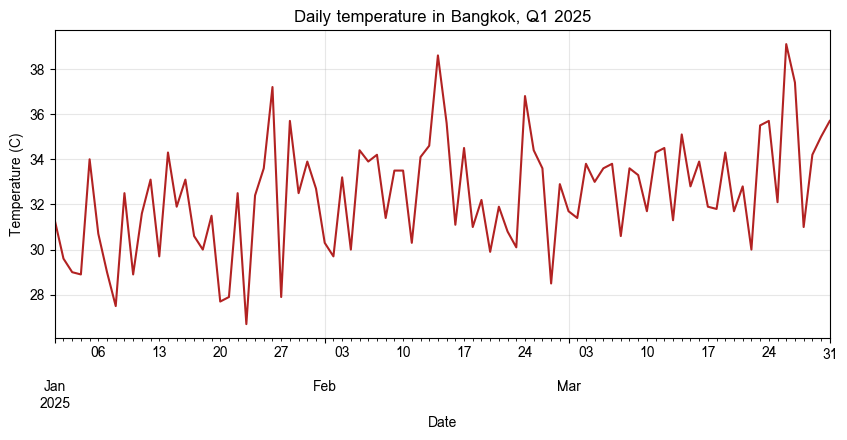

In [219]:
import matplotlib.pyplot as plt
import seaborn as sns

# แนวปฏิบัติที่แนะนำคือสร้าง figure และ axes ขึ้นก่อน แล้วส่ง ax เข้าไปในคำสั่ง plot
bangkok = df[df["city"] == "Bangkok"].sort_values("date")

fig, ax = plt.subplots(figsize=(10, 4))
bangkok.plot(x="date", y="temperature_c", ax=ax, color="firebrick", legend=False)
ax.set_title("Daily temperature in Bangkok, Q1 2025")
ax.set_xlabel("Date")
ax.set_ylabel("Temperature (C)")
ax.grid(alpha=0.3)
plt.show()

### ตัวอย่างที่ 2 กราฟแท่งแนวตั้งและแนวนอน

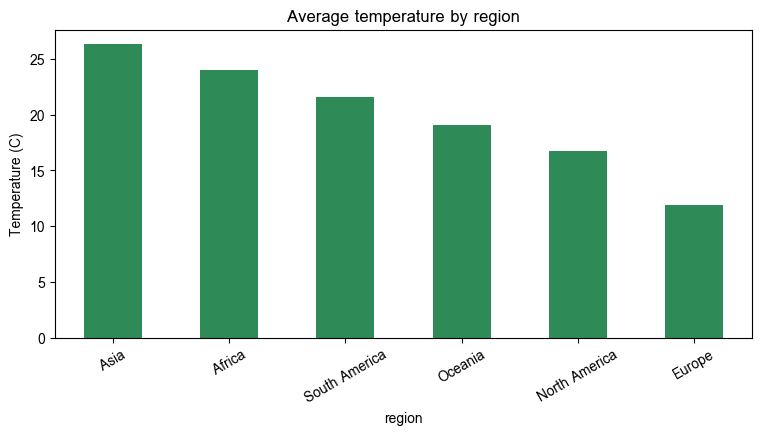

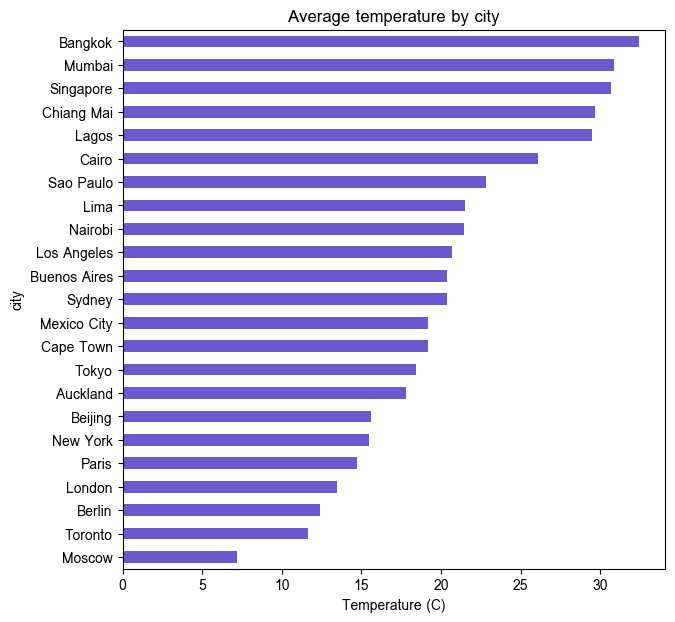

In [220]:
avg_by_region = df.groupby("region")["temperature_c"].mean().sort_values(ascending=False)
fig, ax = plt.subplots(figsize=(9, 4))
avg_by_region.plot(kind="bar", ax=ax, color="seagreen")
ax.set_title("Average temperature by region")
ax.set_ylabel("Temperature (C)")
ax.tick_params(axis="x", rotation=30)
plt.show()

avg_by_city = df.groupby("city")["temperature_c"].mean().sort_values()
fig, ax = plt.subplots(figsize=(7, 7))
avg_by_city.plot(kind="barh", ax=ax, color="slateblue")
ax.set_title("Average temperature by city")
ax.set_xlabel("Temperature (C)")
plt.show()

### ตัวอย่างที่ 3 ฮิสโตแกรม กราฟจุด และ boxplot

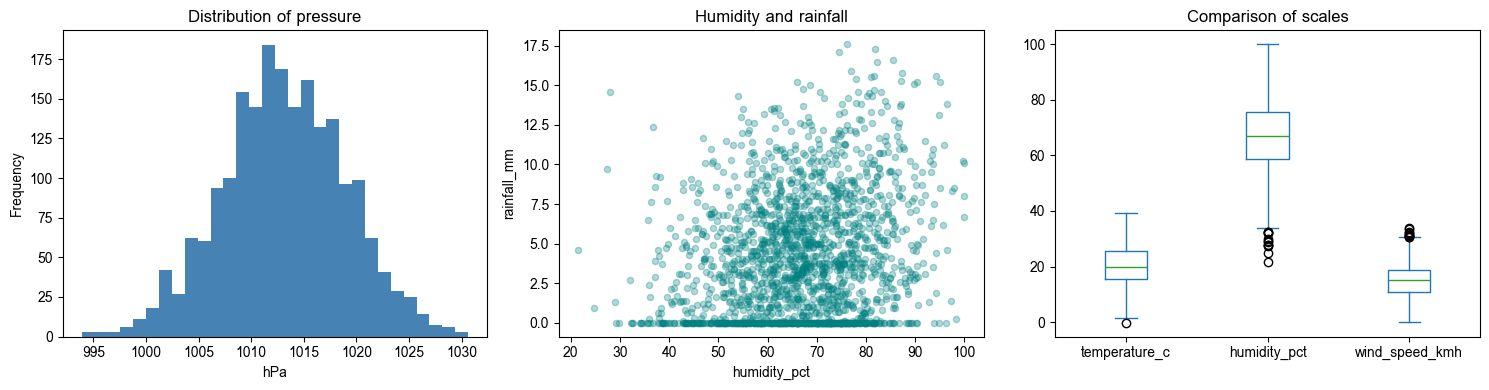

In [221]:
# การวางกราฟหลายรูปในภาพเดียว ให้สร้าง axes เป็นกริดแล้วส่งแต่ละช่องเข้าไปด้วยพารามิเตอร์ ax
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

df["pressure_hpa"].plot(kind="hist", bins=30, ax=axes[0], color="steelblue")
axes[0].set_title("Distribution of pressure")
axes[0].set_xlabel("hPa")

df.plot(kind="scatter", x="humidity_pct", y="rainfall_mm", alpha=0.3, ax=axes[1], color="teal")
axes[1].set_title("Humidity and rainfall")

df[["temperature_c", "humidity_pct", "wind_speed_kmh"]].plot(kind="box", ax=axes[2])
axes[2].set_title("Comparison of scales")

plt.tight_layout()
plt.show()

### ตัวอย่างที่ 4 กราฟวงกลมและการนับสัดส่วน

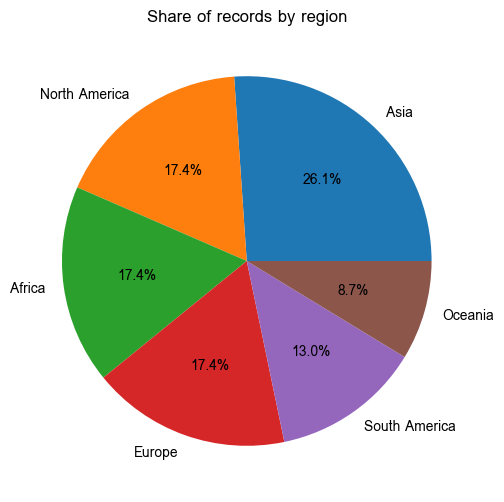

In [222]:
fig, ax = plt.subplots(figsize=(6, 6))
df["region"].value_counts().plot(kind="pie", ax=ax, autopct="%1.1f%%", ylabel="")
ax.set_title("Share of records by region")
plt.show()

### ตัวอย่างที่ 5 การวาดหลายคอลัมน์พร้อมกัน ด้วย `subplots` และ `secondary_y`

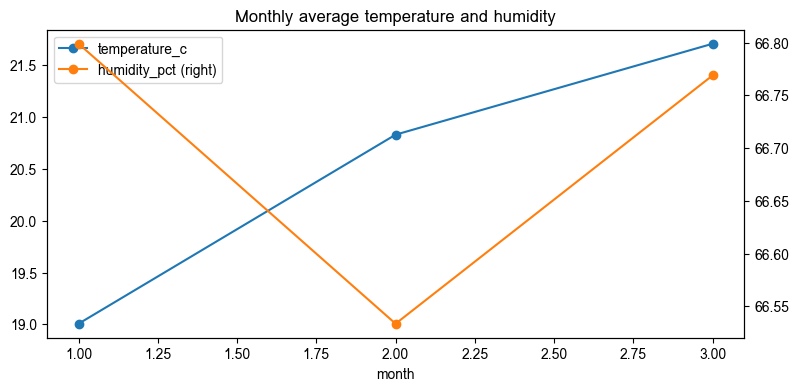

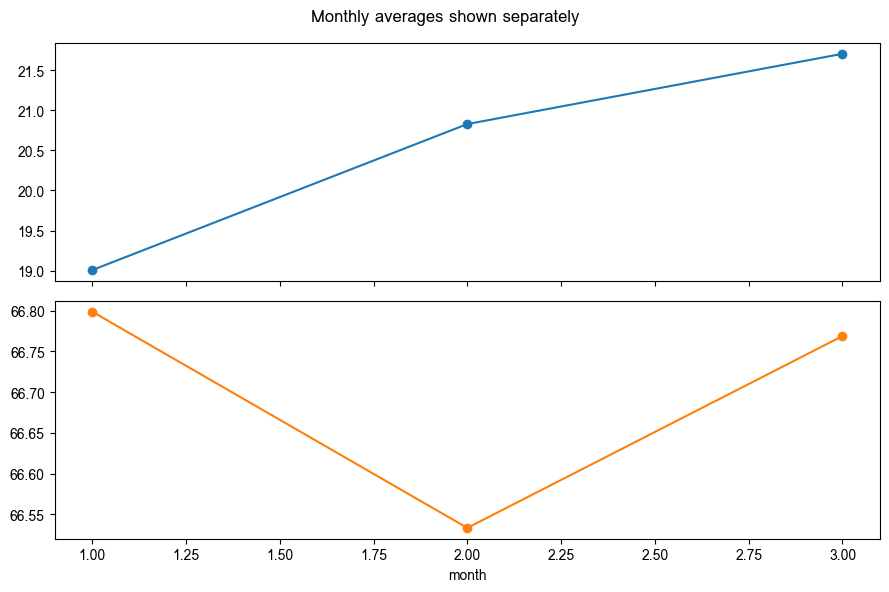

In [223]:
monthly = df.groupby("month")[["temperature_c", "humidity_pct"]].mean()

# secondary_y ใช้แกน y ด้านขวาสำหรับคอลัมน์ที่มีสเกลต่างกันมาก
fig, ax = plt.subplots(figsize=(9, 4))
monthly.plot(ax=ax, marker="o", secondary_y="humidity_pct")
ax.set_title("Monthly average temperature and humidity")
plt.show()

# subplots=True แยกแต่ละคอลัมน์ออกเป็นกราฟย่อย
axes = monthly.plot(subplots=True, layout=(2, 1), figsize=(9, 6), marker="o", legend=False)
plt.suptitle("Monthly averages shown separately")
plt.tight_layout()
plt.show()

### ตัวอย่างที่ 6 กราฟแท่งซ้อนจากตารางไขว้

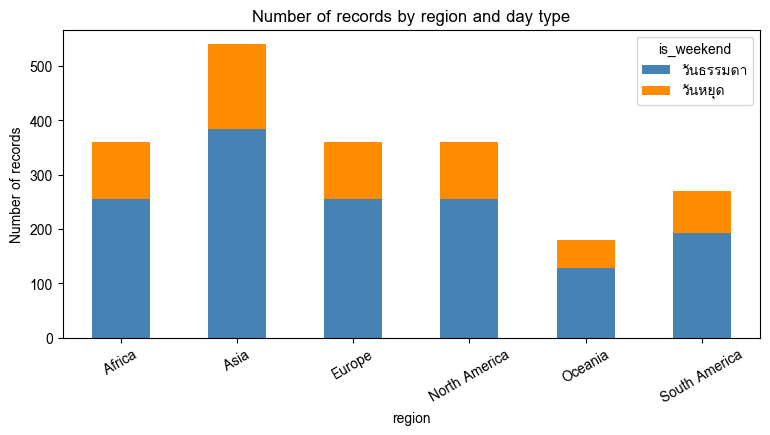

In [224]:
df["is_weekend"] = df["date"].dt.dayofweek >= 5
weekend_by_region = (df.groupby(["region", "is_weekend"]).size()
                       .unstack(fill_value=0)
                       .rename(columns={False: "วันธรรมดา", True: "วันหยุด"}))

fig, ax = plt.subplots(figsize=(9, 4))
weekend_by_region.plot(kind="bar", stacked=True, ax=ax, color=["steelblue", "darkorange"])
ax.set_title("Number of records by region and day type")
ax.set_ylabel("Number of records")
ax.tick_params(axis="x", rotation=30)
plt.show()

### ตัวอย่างที่ 7 กราฟเชิงสถิติด้วย seaborn

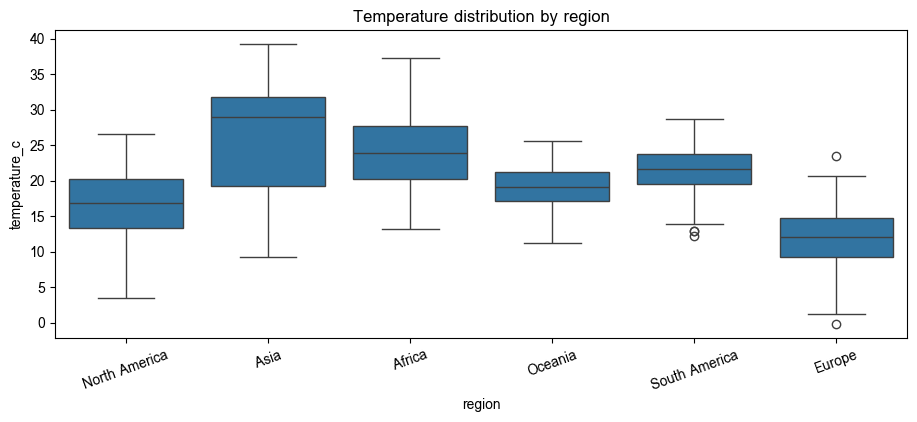

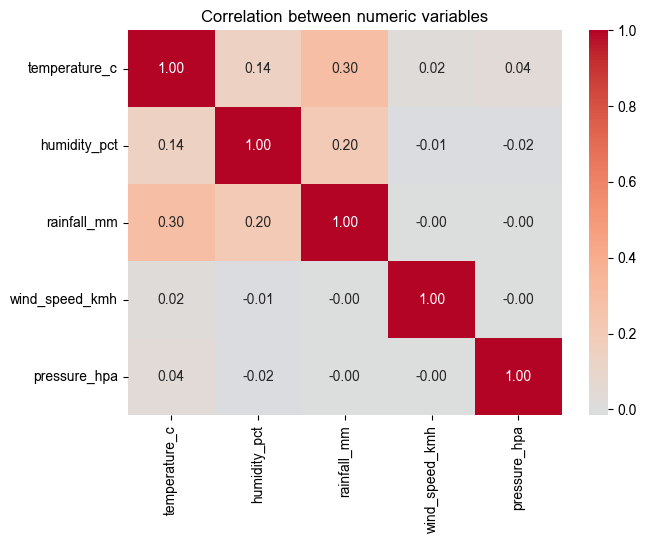

In [225]:
fig, ax = plt.subplots(figsize=(11, 4))
sns.boxplot(data=df, x="region", y="temperature_c", ax=ax)
ax.set_title("Temperature distribution by region")
ax.tick_params(axis="x", rotation=20)
plt.show()

numeric_cols = ["temperature_c", "humidity_pct", "rainfall_mm", "wind_speed_kmh", "pressure_hpa"]
fig, ax = plt.subplots(figsize=(7, 5))
sns.heatmap(df[numeric_cols].corr(), annot=True, fmt=".2f", cmap="coolwarm", center=0, ax=ax)
ax.set_title("Correlation between numeric variables")
plt.show()

### โจทย์ 17.1
สร้างกราฟสี่รูปจาก DataFrame โดยใช้ `.plot()` พร้อมกำหนดชื่อกราฟและชื่อแกนให้ครบทุกรูป

1. กราฟเส้นแสดงแนวโน้มอุณหภูมิรายวันของสามเมืองในรูปเดียวกัน พร้อมคำอธิบายสัญลักษณ์
2. กราฟแท่งแนวนอนแสดงปริมาณฝนรวมรายเมือง เรียงจากมากไปน้อย
3. ฮิสโตแกรมของ `wind_speed_kmh` โดยทดลองกำหนด `bins` สามค่าที่ต่างกันและอธิบายผลของการเลือก `bins`
4. กราฟจุดระหว่าง `population_millions` กับอุณหภูมิเฉลี่ยรายเมือง

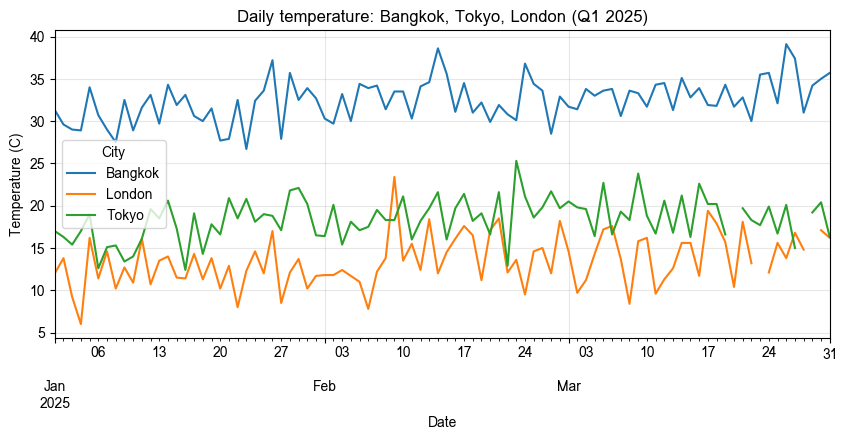

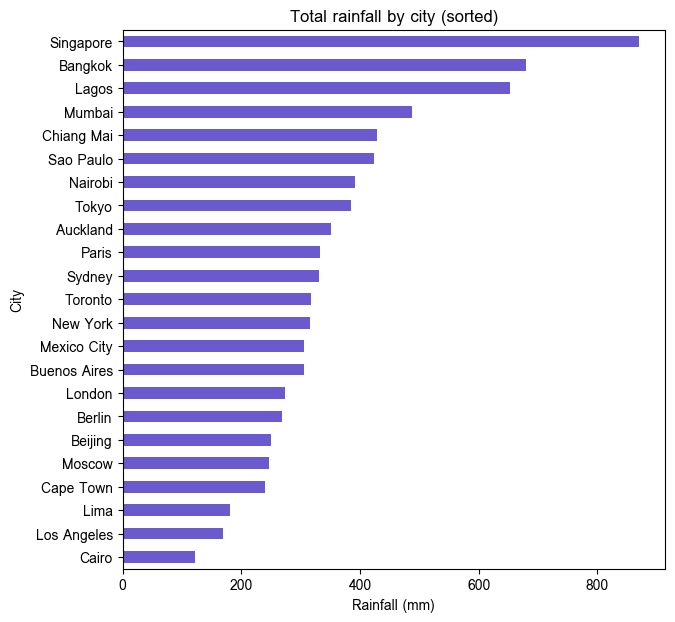

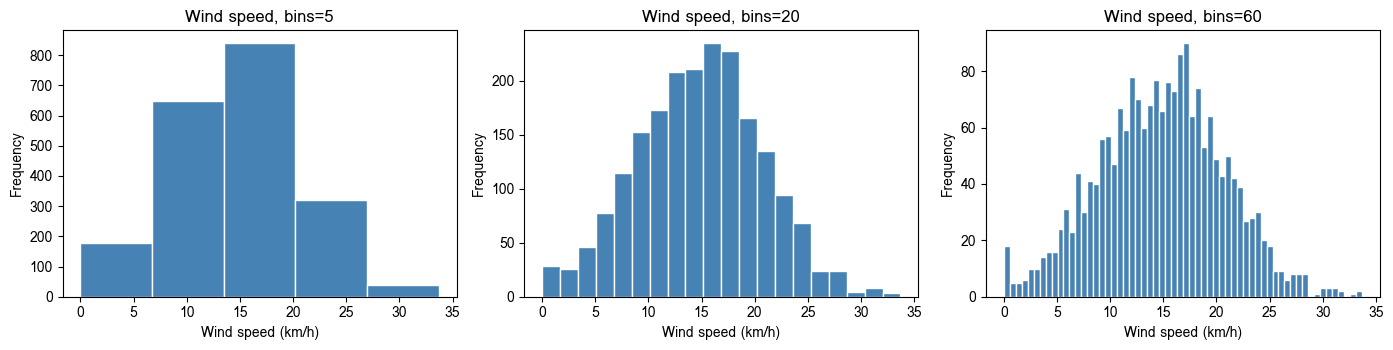

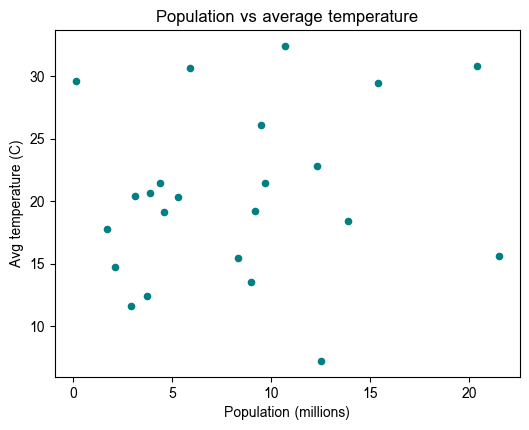

In [226]:
# คำตอบข้อ 17.1
three = ["Bangkok", "Tokyo", "London"]
fig, ax = plt.subplots(figsize=(10, 4))
(df[df["city"].isin(three)].pivot(index="date", columns="city", values="temperature_c")
   .plot(ax=ax))
ax.set_title("Daily temperature: Bangkok, Tokyo, London (Q1 2025)")
ax.set_xlabel("Date"); ax.set_ylabel("Temperature (C)"); ax.legend(title="City"); ax.grid(alpha=0.3)
plt.show()

rain_city = df.groupby("city")["rainfall_mm"].sum().sort_values()
fig, ax = plt.subplots(figsize=(7, 7))
rain_city.plot(kind="barh", ax=ax, color="slateblue")
ax.set_title("Total rainfall by city (sorted)"); ax.set_xlabel("Rainfall (mm)"); ax.set_ylabel("City")
plt.show()

fig, axes = plt.subplots(1, 3, figsize=(14, 3.6), sharey=False)
for ax, b in zip(axes, [5, 20, 60]):
    df["wind_speed_kmh"].plot(kind="hist", bins=b, ax=ax, color="steelblue", edgecolor="white")
    ax.set_title(f"Wind speed, bins={b}"); ax.set_xlabel("Wind speed (km/h)"); ax.set_ylabel("Frequency")
plt.tight_layout(); plt.show()

cc = full.groupby("city").agg(pop=("population_millions", "first"), avg_temp=("temperature_c", "mean"))
fig, ax = plt.subplots(figsize=(6, 4.5))
cc.plot(kind="scatter", x="pop", y="avg_temp", ax=ax, color="teal")
ax.set_title("Population vs average temperature"); ax.set_xlabel("Population (millions)"); ax.set_ylabel("Avg temperature (C)")
plt.show()


•	อธิบายผลของ bins: น้อยเกินไป (5) กล่องใหญ่จนซ่อนรูปร่างการกระจาย มากเกินไป (60) แต่ละกล่องมีค่าน้อย กราฟขรุขระเต็มไปด้วยสัญญาณรบกวน ค่ากลาง ๆ (ราว 20) อ่านภาพรวมได้ชัดที่สุด

•	กราฟจุด ประชากร–อุณหภูมิเฉลี่ย: จุดกระจายไม่เป็นแนว (r ≈ 0.16) ไม่เห็นความสัมพันธ์ชัดเจน


### โจทย์ 17.2
นำผลลัพธ์ของโจทย์ 17.1 มาจัดวางในภาพเดียวกันด้วย `plt.subplots(2, 2)` พร้อมกำหนดชื่อรวมของภาพด้วย `plt.suptitle()`

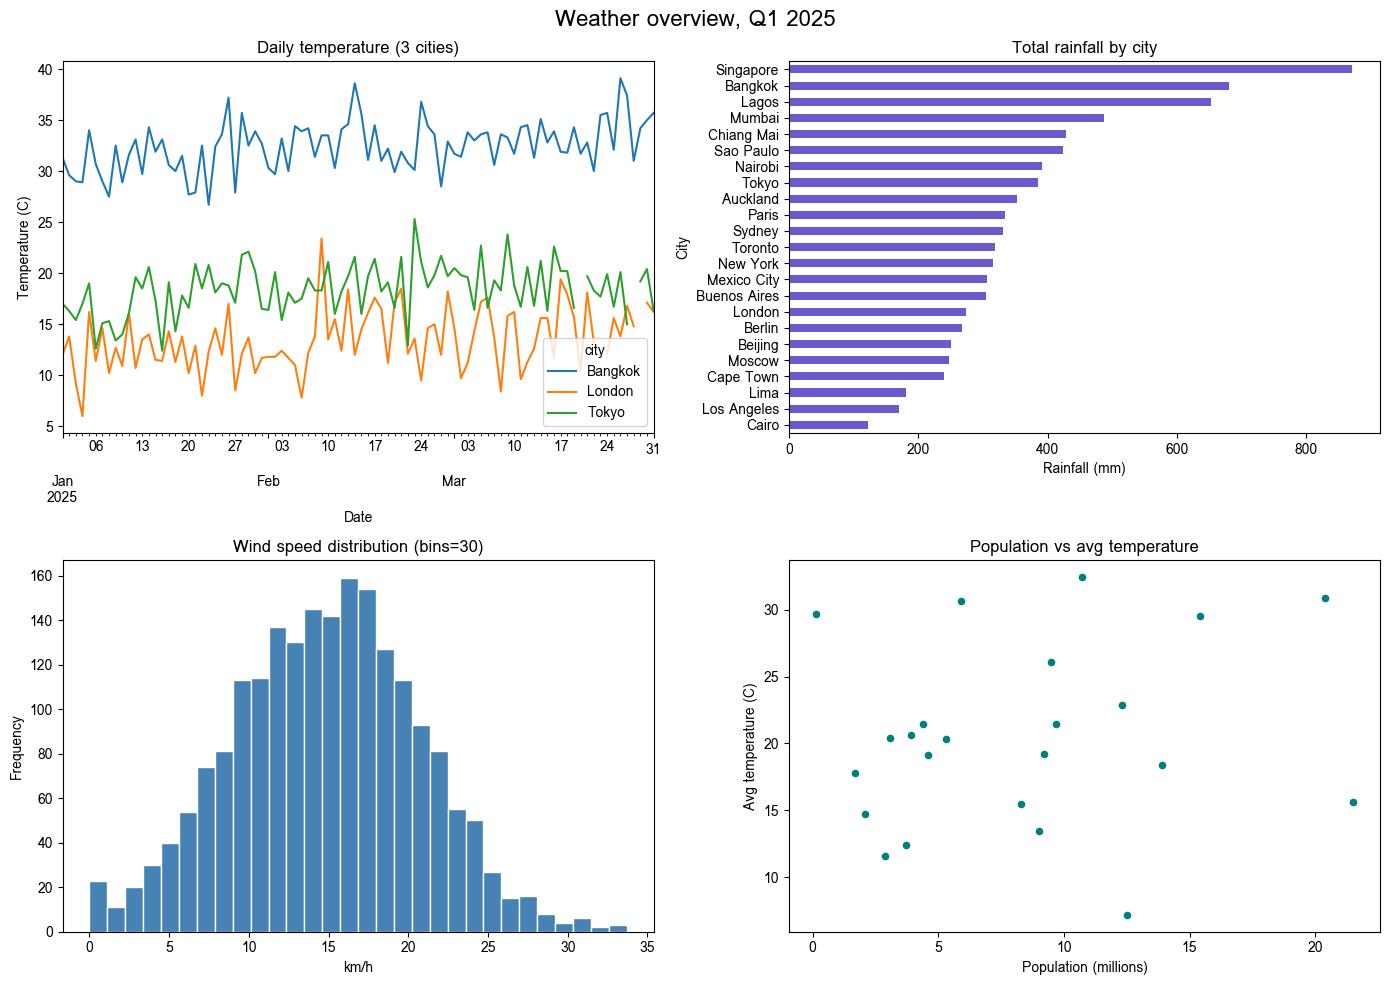

wind skew: -0.01


In [227]:
# คำตอบข้อ 17.2
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
(df[df["city"].isin(three)].pivot(index="date", columns="city", values="temperature_c")
   .plot(ax=axes[0, 0]))
axes[0, 0].set_title("Daily temperature (3 cities)"); axes[0, 0].set_xlabel("Date"); axes[0, 0].set_ylabel("Temperature (C)")
rain_city.plot(kind="barh", ax=axes[0, 1], color="slateblue")
axes[0, 1].set_title("Total rainfall by city"); axes[0, 1].set_xlabel("Rainfall (mm)"); axes[0, 1].set_ylabel("City")
df["wind_speed_kmh"].plot(kind="hist", bins=30, ax=axes[1, 0], color="steelblue", edgecolor="white")
axes[1, 0].set_title("Wind speed distribution (bins=30)"); axes[1, 0].set_xlabel("km/h"); axes[1, 0].set_ylabel("Frequency")
cc.plot(kind="scatter", x="pop", y="avg_temp", ax=axes[1, 1], color="teal")
axes[1, 1].set_title("Population vs avg temperature"); axes[1, 1].set_xlabel("Population (millions)"); axes[1, 1].set_ylabel("Avg temperature (C)")
plt.suptitle("Weather overview, Q1 2025", fontsize=16); plt.tight_layout(); plt.show()
print("wind skew:", round(df["wind_speed_kmh"].skew(), 2))


### โจทย์ 17.3
สร้างกราฟแท่งซ้อนแสดงจำนวนวันในแต่ละช่วงปริมาณฝน โดยแบ่งช่วงด้วย `pd.cut()` และจำแนกตามภูมิภาค
จากนั้นสร้างกราฟแบบ `stacked=False` เปรียบเทียบ
**อธิบาย:** กราฟแท่งซ้อนเหมาะสมกว่าในกรณีใด และกราฟแท่งเรียงข้างกันเหมาะสมกว่าในกรณีใด

region       Africa  Asia  Europe  North America  Oceania  South America
rainfall_mm                                                             
<=0.5           112    69     115            111       40             84
0.5-5           118   164     147            142       63            106
5-10             88   203      73             84       60             52
>10              31    90      15             11        9             21


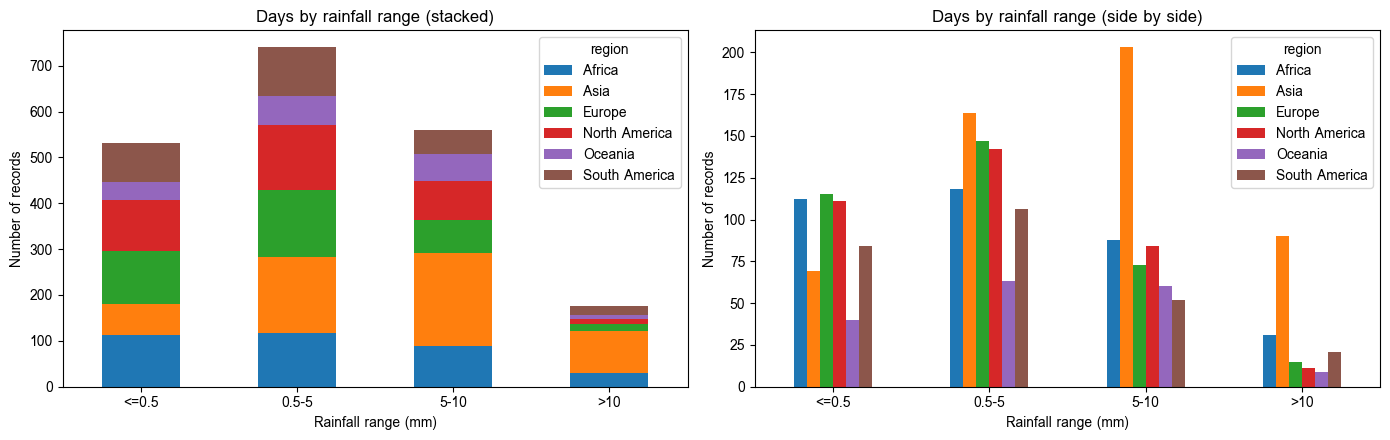

In [228]:
# คำตอบข้อ 17.3
rain_bin = pd.cut(df["rainfall_mm"], bins=[-0.01, 0.5, 5, 10, np.inf],
                  labels=["<=0.5", "0.5-5", "5-10", ">10"])
ct = pd.crosstab(rain_bin, df["region"])
print(ct)
fig, axes = plt.subplots(1, 2, figsize=(14, 4.5))
ct.plot(kind="bar", stacked=True, ax=axes[0]); axes[0].set_title("Days by rainfall range (stacked)")
ct.plot(kind="bar", stacked=False, ax=axes[1]); axes[1].set_title("Days by rainfall range (side by side)")
for ax in axes:
    ax.set_xlabel("Rainfall range (mm)"); ax.set_ylabel("Number of records"); ax.tick_params(axis="x", rotation=0)
plt.tight_layout(); plt.show()


อธิบาย: แท่งซ้อนเหมาะเมื่อสนใจยอดรวมและส่วนประกอบ (แต่ละภูมิภาคมีส่วนร่วมเท่าไรในช่วงฝนนั้น) แท่งเรียงข้างกันเหมาะเมื่อต้องการเทียบค่าของแต่ละภูมิภาคโดยตรง เพราะทุกแท่งเริ่มจากศูนย์เหมือนกัน (ในแท่งซ้อนมีเพียงชั้นล่างสุดที่เทียบตรง ๆ ได้)

### โจทย์ 17.4
สร้างกราฟด้วย seaborn สองรูป ได้แก่ boxplot ของ `rainfall_mm` จำแนกตามภูมิภาคและแยกสีตาม `is_weekend`
และ heatmap ของสหสัมพันธ์ระหว่าง `temperature_c`, `humidity_pct`, `rainfall_mm` และ `population_millions`
พร้อมตีความผลที่ได้เป็นข้อความ

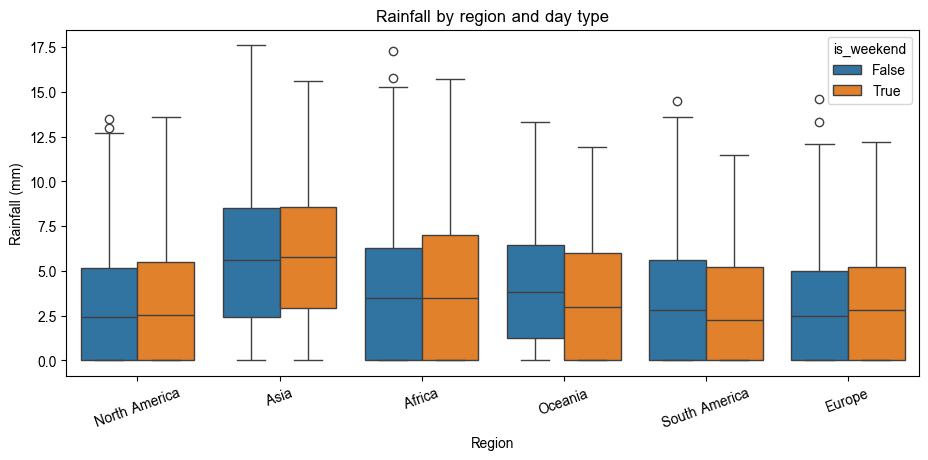

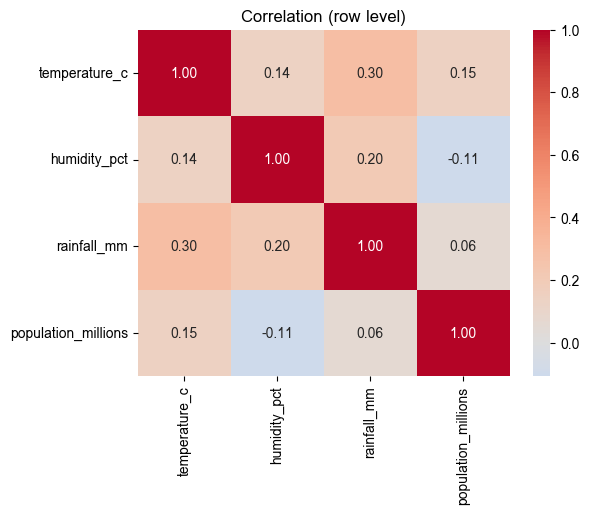

                     temperature_c  humidity_pct  rainfall_mm  \
temperature_c                1.000         0.136        0.297   
humidity_pct                 0.136         1.000        0.204   
rainfall_mm                  0.297         0.204        1.000   
population_millions          0.146        -0.107        0.061   

                     population_millions  
temperature_c                      0.146  
humidity_pct                      -0.107  
rainfall_mm                        0.061  
population_millions                1.000  
is_weekend     False  True 
region                     
Africa           3.5   3.50
Asia             5.6   5.80
Europe           2.5   2.80
North America    2.4   2.55
Oceania          3.8   3.00
South America    2.8   2.25


In [229]:
# คำตอบข้อ 17.4
import matplotlib.pyplot as plt
import seaborn as sns

# เติม is_weekend ให้ df และสร้าง full ใหม่ (รวมประชากรจาก city_info)
df["is_weekend"] = pd.to_datetime(df["date"]).dt.dayofweek >= 5
full = (df.drop(columns=[c for c in ["population_millions", "timezone"] if c in df.columns])
          .merge(city_info[["city", "population_millions", "timezone"]], on="city", how="left"))

fig, ax = plt.subplots(figsize=(11, 4.5))
sns.boxplot(data=df, x="region", y="rainfall_mm", hue="is_weekend", ax=ax)
ax.set_title("Rainfall by region and day type"); ax.set_xlabel("Region"); ax.set_ylabel("Rainfall (mm)")
ax.tick_params(axis="x", rotation=20); plt.show()

cols4 = ["temperature_c", "humidity_pct", "rainfall_mm", "population_millions"]
corr4 = full[cols4].corr()
fig, ax = plt.subplots(figsize=(6, 4.5))
sns.heatmap(corr4, annot=True, fmt=".2f", cmap="coolwarm", center=0, ax=ax)
ax.set_title("Correlation (row level)"); plt.show()

print(corr4.round(3))
print(full.groupby(["region", "is_weekend"])["rainfall_mm"].median().unstack().round(2))

---
## ข้อ 18 โจทย์ประยุกต์รวม

ให้ใช้ตารางที่รวมข้อมูลจากทั้ง 3 แหล่งและผ่านการทำความสะอาดแล้ว ตอบคำถามต่อไปนี้
แต่ละข้อต้องประกอบด้วย **ตารางหรือกราฟหนึ่งชิ้น** และ **ข้อสรุปเป็นข้อความสั้น ๆ**

**ข้อกำหนดเพิ่มเติม**

- ให้เขียนโปรแกรมในรูปแบบลำดับต่อเนื่องที่อ่านเข้าใจได้ ไม่ใช้ตัวแปรชั่วคราวจำนวนมากโดยไม่จำเป็น
- ห้ามใช้การวนซ้ำทีละแถว
- หากข้อสรุปขึ้นอยู่กับวิธีจัดการค่าว่างหรือค่าผิดปกติ ให้ระบุวิธีที่เลือกใช้ไว้ด้วย

1. ภูมิภาคใดมีสภาพอากาศแปรปรวนมากที่สุดในไตรมาสแรก เมื่อวัดจากส่วนเบี่ยงเบนมาตรฐานของอุณหภูมิรายวัน
   และความแปรปรวนดังกล่าวเกิดจากทุกเมืองในภูมิภาคนั้นเท่ากันหรือเกิดจากเมืองใดเมืองหนึ่งเป็นหลัก

In [230]:
# คำตอบข้อ 18.1
by_region = full.groupby("region")["temperature_c"].agg(std_total="std", n="count").round(2)
within = full.groupby(["region", "city"])["temperature_c"].std().groupby("region").mean().rename("mean_within_city_std")
between = full.groupby(["region", "city"])["temperature_c"].mean().groupby("region").std().rename("std_of_city_means")
t18 = pd.concat([by_region, within, between], axis=1).round(2).sort_values("std_total", ascending=False)
print(t18)
top_r = t18.index[0]
cstd = full[full.region == top_r].groupby("city")["temperature_c"].agg(mean="mean", std="std").round(2)
print(top_r); print(cstd)


               std_total    n  mean_within_city_std  std_of_city_means
region                                                                
Asia                7.16  535                  2.67               7.28
Africa              4.88  352                  2.79               4.64
North America       4.52  357                  2.87               4.05
Europe              4.07  354                  2.88               3.32
Oceania             3.08  180                  2.81               1.80
South America       3.06  267                  2.89               1.23
Asia
             mean   std
city                   
Bangkok     32.44  2.49
Beijing     15.60  2.87
Chiang Mai  29.65  2.86
Mumbai      30.87  2.54
Singapore   30.64  2.71
Tokyo       18.41  2.52


Asia ผันผวนที่สุด (std ของอุณหภูมิรายวัน = 7.16 °C) รองลงมา Africa 4.88 และ North America 4.52

ความผันผวนเกิดจากความต่างระหว่างเมือง ไม่ใช่เมืองใดเมืองหนึ่ง: std ภายในแต่ละเมืองของ Asia ใกล้เคียงกัน (2.49–2.87 °C) และเท่ากับภูมิภาคอื่น แต่ค่าเฉลี่ยของเมืองต่างกันมาก (Beijing 15.6, Tokyo 18.4 เทียบกับ Bangkok 32.4, Mumbai 30.9) std ของค่าเฉลี่ยเมืองจึงสูงถึง 7.28


2. เมืองที่มีฝนตกหนักบ่อยที่สุด 5 อันดับแรกเมื่อวัดด้วยสัดส่วน ให้เปรียบเทียบกับผลที่ได้เมื่อวัดด้วยจำนวนวัน
   และอธิบายว่าเหตุใดจึงให้ผลต่างกัน

In [231]:
# คำตอบข้อ 18.2
t182 = pd.DataFrame({"heavy_days": heavy_cnt, "valid_days": valid_days,
                     "heavy_prop": (heavy_cnt / valid_days)})
print(t182.nlargest(5, "heavy_prop").round(3)); print(t182.nlargest(5, "heavy_days").round(3))
print(t182.sort_values("heavy_days", ascending=False).head(8).round(3))


            heavy_days  valid_days  heavy_prop
city                                          
Singapore           44          90       0.489
Bangkok             23          87       0.264
Lagos               22          88       0.250
Sao Paulo           11          88       0.125
Chiang Mai           9          85       0.106
              heavy_days  valid_days  heavy_prop
city                                            
Singapore             44          90       0.489
Bangkok               23          87       0.264
Lagos                 22          88       0.250
Sao Paulo             11          88       0.125
Buenos Aires           9          88       0.102
              heavy_days  valid_days  heavy_prop
city                                            
Singapore             44          90       0.489
Bangkok               23          87       0.264
Lagos                 22          88       0.250
Sao Paulo             11          88       0.125
Chiang Mai             9          

•	ตามสัดส่วน: Singapore, Bangkok, Lagos, Sao Paulo, Chiang Mai   ตามจำนวนวัน: Singapore, Bangkok, Lagos, Sao Paulo, Buenos Aires (Chiang Mai 9 วันเท่ากัน)

•	ต่างกันเฉพาะอันดับ 5 เพราะ Chiang Mai มีข้อมูลฝนเพียง 85 วัน (9/85 = 10.6%) ขณะที่ Buenos Aires มี 88 วัน (9/88 = 10.2%) จำนวนวันไม่คิดฐานที่ต่างกัน สัดส่วนจึงยุติธรรมกว่า


3. จำนวนประชากรของเมืองมีความสัมพันธ์กับอุณหภูมิหรือปริมาณฝนหรือไม่
   ให้คำนวณค่าสหสัมพันธ์ประกอบ พร้อมระบุข้อควรระวังในการตีความอย่างน้อยหนึ่งประการ

In [232]:
# คำตอบข้อ 18.3
cc2 = full.groupby("city").agg(pop=("population_millions", "first"), avg_temp=("temperature_c", "mean"),
                               avg_rain=("rainfall_mm", "mean"))
print(cc2.corr().round(3)); print(cc2.corr(method="spearman").round(3))
print(cc2["pop"].describe().round(2))
print(cc2.drop(index=["Beijing", "Chiang Mai"]).corr().round(3))


            pop  avg_temp  avg_rain
pop       1.000     0.159     0.123
avg_temp  0.159     1.000     0.639
avg_rain  0.123     0.639     1.000
            pop  avg_temp  avg_rain
pop       1.000     0.230     0.057
avg_temp  0.230     1.000     0.496
avg_rain  0.057     0.496     1.000
count    23.00
mean      8.27
std       5.78
min       0.13
25%       3.80
50%       8.30
75%      11.50
max      21.50
Name: pop, dtype: float64
            pop  avg_temp  avg_rain
pop       1.000     0.412     0.275
avg_temp  0.412     1.000     0.633
avg_rain  0.275     0.633     1.000


•	คำนวณระดับเมือง (23 จุด): ประชากร–อุณหภูมิเฉลี่ย r = 0.16, ประชากร–ฝนเฉลี่ย r = 0.12 → ไม่มีความสัมพันธ์ชัดเจน (อุณหภูมิ–ฝนเฉลี่ย r = 0.64)

•	ข้อควรระวัง: ค่า r ไวต่อค่าสุดโต่ง ตัด Beijing (21.5 ล้าน) และ Chiang Mai (0.13 ล้าน) ออก r ของประชากร–อุณหภูมิเพิ่มจาก 0.16 เป็น 0.41 นอกจากนี้สหสัมพันธ์ไม่ใช่เหตุและผล และมีเพียง 23 เมืองกับข้อมูล 3 เดือน


4. เดือนใดของแต่ละภูมิภาคที่ควรหลีกเลี่ยงการเดินทางมากที่สุด
   ให้กำหนดเกณฑ์การตัดสินใจจากข้อมูลที่มีอยู่ และอธิบายเหตุผลของการเลือกเกณฑ์ดังกล่าว

month             1     2     3
region                         
Africa         12.9   9.8  10.5
Asia           20.4  25.0  22.0
Europe          6.5   8.0   8.9
North America   5.6   6.2   7.3
Oceania         6.5   5.4   9.7
South America  11.8   9.5  11.8
region
Africa           1
Asia             2
Europe           3
North America    3
Oceania          3
South America    1
Name: worst_month, dtype: int32


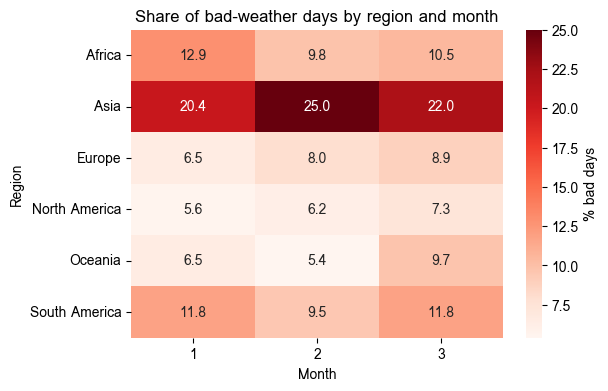

In [233]:
# คำตอบข้อ 18.4
full["bad_day"] = ((full["rainfall_mm"] > 10) | (full["wind_speed_kmh"] > 25) |
                   (full["temperature_c"] > 35) | (full["temperature_c"] < 0))
bad_rate = full.groupby(["region", "month"])["bad_day"].mean().unstack().mul(100).round(1)
print(bad_rate)
print(bad_rate.idxmax(axis=1).rename("worst_month"))
fig, ax = plt.subplots(figsize=(6, 4))
sns.heatmap(bad_rate, annot=True, fmt=".1f", cmap="Reds", ax=ax, cbar_kws={"label": "% bad days"})
ax.set_title("Share of bad-weather days by region and month"); ax.set_xlabel("Month"); ax.set_ylabel("Region")
plt.show()


•	เกณฑ์ "วันแย่": ฝน > 10 mm หรือ ลม > 25 km/h หรือ อุณหภูมิ > 35 หรือ < 0 °C แล้วดูสัดส่วนวันแย่รายภูมิภาค-เดือน เดือนที่ควรเลี่ยงที่สุด: Africa ม.ค. (12.9%), Asia ก.พ. (25.0%), Europe มี.ค. (8.9%), North America มี.ค. (7.3%), Oceania มี.ค. (9.7%), South America ม.ค. (11.8% เสมอกับ มี.ค.)

•	เหตุผลของเกณฑ์: นักเดินทางรู้สึกถึงวันที่เลวร้ายมากกว่าค่าเฉลี่ยของเดือน การนับสัดส่วนวันจึงสื่อความหมายตรงกว่า ข้อจำกัด: ค่าว่างถูกนับเป็นไม่แย่ และมีข้อมูลเพียง 3 เดือน


---

<center>จบแล้ว ขอแสดงความยินดีกับทุกคน

<center>> เขียนเองหนึ่งบรรทัด ได้ความเข้าใจมากกว่าอ่านผ่านตาสิบบรรทัด
> One line you write yourself teaches more than ten you only read.

> คนที่จัดการข้อมูลสองพันแถวได้อย่างสะอาดหมดจด คือคนเดียวกับที่จะจัดการข้อมูลสองล้านแถวได้อย่างมั่นใจ
> Whoever handles two thousand rows with care will handle two million with confidence.

<center>❤️❤️❤️❤️❤️ Keep Learning ❤️❤️❤️❤️❤️